#Day25. 머신러닝기초
---


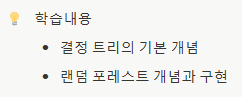

###Day24 수업 이어서 진행

##**모델 성능 평가 및 다중 분류 개념**

머신러닝 모델의 성능을 평가하는 것은 모델의 **정확성, 일반화 성능, 실무 적용 가능성**을 판단하는 중요한 과정  
특히 로지스틱 회귀 같은 이진 분류(Binary Classification) 모델과 다중 분류(Multi-Class Classification) 모델을 평가하는 방법이 다를 수 있음

##**1. 모델 성능 평가 방법**

### **1) 정확도(Accuracy)**

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

- 전체 샘플 중 **올바르게 분류된 비율**을 의미
- 정확도가 높을수록 모델이 데이터를 잘 예측하고 있다고 볼 수 있음
- 하지만 **데이터가 불균형한 경우(Positive/Negative 비율 차이가 클 때), 정확도만으로 평가하면 모델 성능을 과대평가할 가능성이 있음**

### **(2) 정밀도(Precision)**

$$
Precision = \frac{TP}{TP + FP}
$$

- 모델이 **긍정 클래스(1, Positive)** 라고 예측한 것 중 실제로 맞춘 비율을 의미
- **FP(실제로는 0인데 1이라고 예측한 경우)를 줄이는 데 초점**을 맞춤
- 예제:
    - **스팸 메일 분류**에서 Precision이 높다면, 정상 메일을 스팸으로 분류하는 실수를 줄일 수 있음

### **(3) 재현율(Recall)**

$$
Recall = \frac{TP}{TP + FN}
$$

- 실제로 **긍정 클래스(1, Positive)** 인 샘플 중 모델이 맞춘 비율을 의미
- **FN(실제로 1인데 0으로 예측한 경우)를 줄이는 데 초점**을 맞춤
- 예제:
    - **암 진단 모델**에서는 Recall이 높을수록 실제 암 환자를 놓치는 경우가 적음

### **(4) F1-Score**

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

- 정밀도(Precision)와 재현율(Recall)의 **조화 평균**
- 데이터 불균형이 심한 경우, 단순한 정확도(Accuracy)보다 더 신뢰할 수 있는 평가 지표
- Precision과 Recall 간 균형을 맞추는 데 유용함

### **(5) ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**

- ROC 곡선은 **모델의 분류 성능을 시각적으로 평가하는 방법**
- AUC 값이 1에 가까울수록 **모델이 긍정 클래스와 부정 클래스를 잘 구분**한다는 의미
- **임계값(Threshold)에 따라 Precision-Recall이 변화하는 경향을 분석 가능**



---

##**2. 다중 분류 (Multi-Class Classification)**

이진 분류(Binary Classification)는 두 개의 클래스를 구분하는 문제이지만,

**다중 분류(Multi-Class Classification)** 는 **세 개 이상의 클래스를 분류하는 문제**이다.

예제:

- **손글씨 숫자 인식 (MNIST 데이터셋)** → 0~9까지의 10개 숫자를 분류
- **상품 추천 시스템** → 고객을 여러 구매 성향(High-Spender, Medium-Spender, Low-Spender)으로 분류

### **(1) 소프트맥스 함수(Softmax Function)**

로지스틱 회귀는 **이진 분류**에서 시그모이드(Sigmoid) 함수를 사용하지만,

다중 분류에서는 **소프트맥스(Softmax) 함수** 사용

$$
P(y_i) = \frac{e^{z_i}}{\sum_{j=1}^{N} e^{z_j}}
$$

- 소프트맥스 함수는 각 클래스에 대한 **확률 값**을 출력하며, 확률 합은 항상 **1**이 됨
- 가장 확률이 높은 클래스를 최종 예측값으로 선택

### **(2) One-vs-Rest (OvR) 방식**

- 각 클래스를 **이진 분류 문제로 변환하여 여러 개의 로지스틱 회귀 모델을 훈련**하는 방식
- 예제 (0~9 숫자 분류):
    - "0"과 "나머지", "1"과 "나머지", ..., "9"와 "나머지" 총 10개의 모델을 학습
- 간단하고 빠르게 학습 가능하지만, 클래스 간 상관관계 학습이 어려울 수 있음

### **(3) One-vs-One (OvO) 방식**

- 각 두 개의 클래스를 비교하는 방식으로 $N(N-1)/2$ **개의 모델을 학습**
- 예제 (0~9 숫자 분류):
    - (0,1), (0,2), (0,3), ..., (8,9) 총 **45개의 모델**을 학습
- 데이터가 많을 경우 계산량이 많아질 수 있음



---

## **3. 다중 분류 모델 평가 방법**

이진 분류와 마찬가지로 다중 분류에서도 **정확도, Precision, Recall, F1-score** 등을 활용하여 모델 성능을 평가할 수 있음

다만 다중 분류에서는 **각 클래스별로 Precision, Recall, F1-score를 구한 후 평균을 내는 방법** 사용

### **(1) 매크로 평균(Macro Average)**

- 각 클래스별 Precision, Recall, F1-score를 계산한 후 **평균을 구함**
- 클래스의 **샘플 수와 관계없이 동일한 가중치**를 부여
- **클래스 균형이 맞을 때 적절한 평가 방식**

$$
\text{Macro-F1} = \frac{1}{N} \sum_{i=1}^{N} F1_i
$$

### **(2) 가중 평균(Weighted Average)**

- 클래스별 샘플 수(가중치)를 반영하여 평균을 계산
- **데이터 불균형이 존재할 때 더 적절한 평가 방식**

$$
\text{Weighted-F1} = \frac{\sum_{i=1}^{N} w_i F1_i}{\sum w_i}
$$

### **(3) 마이크로 평균(Micro Average)**

- 전체 샘플을 기준으로 TP, FP, FN을 합산하여 Precision, Recall, F1-score를 계산
- **샘플 개수가 많을수록 더 높은 비중을 반영**



---

##**4. 모델 평가 및 다중 분류 실습 코드**

In [7]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


정확도(Accuracy): 0.975
분류 보고서(Classification Report):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



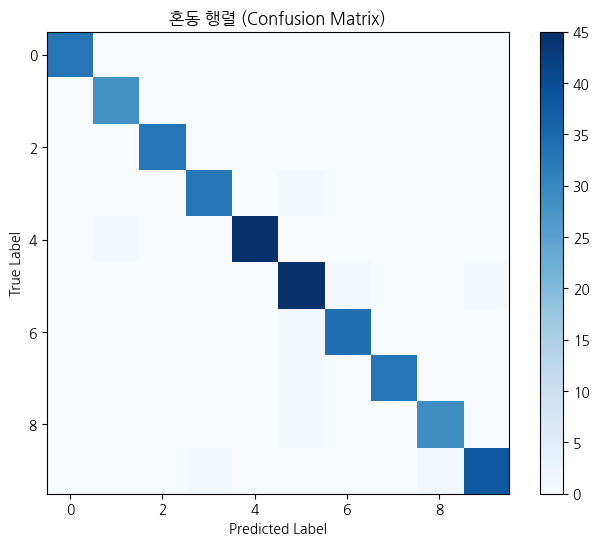

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_digits

# 다중 클래스 데이터셋 로드 (손글씨 숫자 데이터)
digits = load_digits()
X = digits.data
y = digits.target

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 다중 분류 로지스틱 회귀 모델 학습 (소프트맥스 사용)
model = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs")
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)

print("정확도(Accuracy):", model.score(X_test, y_test))
print("분류 보고서(Classification Report):\n", classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8,6))
plt.imshow(confusion_matrix(y_test, y_pred), cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title("혼동 행렬 (Confusion Matrix)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


- 모델 성능을 평가할 때 **Accuracy, Precision, Recall, F1-score, ROC-AUC** 등을 활용해야 함
- **이진 분류와 다중 분류는 평가 방식이 다르며, 다중 분류에서는 Macro, Weighted, Micro 평균을 고려해야 함**
- 실전에서는 **클래스 불균형 여부를 고려하여 적절한 평가 방법을 선택**하는 것이 중요



---

다음은 로지스틱 회귀(Logistic Regression)를 이용한 **다중 분류(Multiclass Classification)** 예시입니다.

### **시나리오**

기업이 고객을 대상으로 온라인 마케팅 캠페인을 진행하고 있다. 각 고객의 **나이, 소비 점수, 광고 클릭률, 이메일 오픈율**을 바탕으로 **고객이 해당 캠페인에 얼마나 적극적으로 반응할지(High, Medium, Low)** 예측하는 모델을 개발한다. 이 모델을 활용하여 **타겟 고객을 분류하고 맞춤형 마케팅 전략을 수립**할 수 있다.

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

# 1. 가상의 마케팅 데이터 생성
data = {
    'age': [22, 45, 25, 47, 35, 50, 29, 41, 60, 33, 39, 28, 42, 23, 37],
    'spending_score': [80, 55, 90, 40, 70, 35, 85, 50, 20, 75, 65, 88, 45, 95, 60],
    'ad_click_rate': [0.9, 0.3, 0.8, 0.2, 0.7, 0.1, 0.85, 0.4, 0.05, 0.75, 0.6, 0.88, 0.35, 0.92, 0.5],
    'email_open_rate': [0.95, 0.4, 0.9, 0.3, 0.75, 0.2, 0.89, 0.5, 0.1, 0.78, 0.65, 0.91, 0.37, 0.96, 0.55],
    'engagement_level': ['High', 'Medium', 'High', 'Low', 'High', 'Low', 'High', 'Medium', 'Low',
                         'High', 'Medium', 'High', 'Medium', 'High', 'Medium']
}

df = pd.DataFrame(data)

# 2. 독립변수(X)와 종속변수(y) 설정
X = df[['age', 'spending_score', 'ad_click_rate', 'email_open_rate']]
y = df['engagement_level']

# 3. 라벨 인코딩 (문자 → 숫자 변환)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. 훈련/테스트 데이터 분할 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# 6. 로지스틱 회귀 모델 훈련 (다중 분류)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# 7. 테스트 데이터 예측
y_pred = model.predict(X_test)

# 8. 예측 결과 출력
print("테스트 데이터 예측 결과:")
for i, pred in enumerate(y_pred):
    print(f"테스트 데이터 {i+1}: 예측된 참여 수준 - {label_encoder.inverse_transform([pred])[0]}")


테스트 데이터 예측 결과:
테스트 데이터 1: 예측된 참여 수준 - Medium
테스트 데이터 2: 예측된 참여 수준 - Medium
테스트 데이터 3: 예측된 참여 수준 - High
테스트 데이터 4: 예측된 참여 수준 - High
테스트 데이터 5: 예측된 참여 수준 - High


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### **활용 방안**

- 기업은 고객의 행동 패턴을 분석하여 **적극적인 반응을 보일 고객층(High Engagement)** 을 대상으로 집중적인 마케팅 전략을 수행할 수 있음
- 반대로, **반응이 낮은 고객층(Low Engagement)** 에게는 보다 효과적인 광고 소재나 재참여 유도 전략을 제공할 수 있음
- 데이터를 지속적으로 업데이트하여 **모델의 예측 성능을 개선**할 수 있음



---



#**결정 트리 (Decision Tree)**

결정 트리(Decision Tree)는 트리(Tree) 구조를 사용하여 데이터를 분류(Classification)하거나 회귀(Regression)하는 지도 학습(Supervised Learning) 알고리즘  
트리의 각 노드는 **특정 특징(feature)을 기준으로 데이터를 나누는 역할**을 하며, 최종적으로 예측값(클래스 또는 수치) 도출

##**1. 결정 트리의 구조**

- **루트 노드(Root Node)**:
    - 데이터가 처음 입력되는 노드
    - 가장 중요한 특징(Feature)을 기준으로 데이터를 나누는 역할
- **내부 노드(Internal Nodes)**:
    - 특정 특징을 기준으로 데이터를 **분할(Split)** 하는 역할
    - 각 노드는 질문(조건문)을 포함하며, 예/아니오(Yes/No) 또는 특정 범위에 따라 데이터를 나눔
- **가지(Branches)**:
    - 하나의 노드에서 데이터를 나누는 경로
    - 각 조건을 만족하는 데이터는 새로운 노드(자식 노드)로 이동
- **단말 노드(Leaf Nodes)**:
    - 더 이상 데이터를 나누지 않는 최종 노드
    - 분류 문제에서는 **클래스(0, 1, …)** 를 나타내고, 회귀 문제에서는 **수치 예측 값**을 나타냄

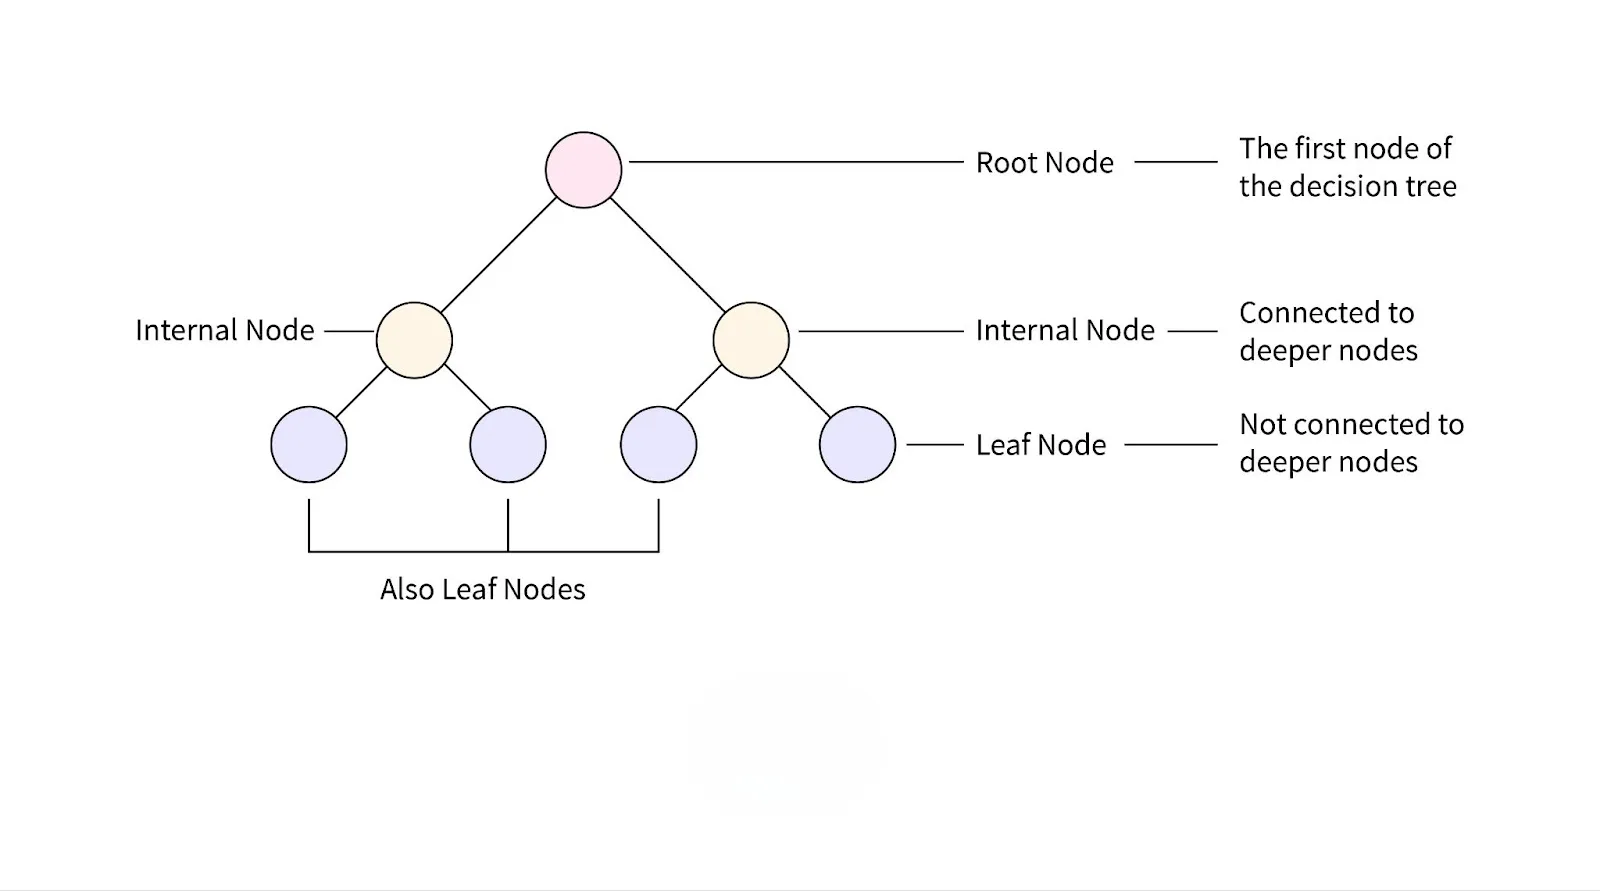

##**2. 결정 트리 학습 과정**

 데이터를 기반으로 최적의 특징(feature)과 분할 조건(Split Condition)을 찾아 트리를 성장시키는 방식으로 학습

### **(1) 분할 기준(Splitting Criteria)**

- 결정 트리는 데이터를 분할할 때 **어떤 특징(feature)이 가장 효과적으로 데이터를 나눌 수 있는지**를 평가해야 함
- 이를 위해 **엔트로피(Entropy)와 지니 지수(Gini Index)** 같은 수식을 사용하여 **정보 이득(Information Gain)** 을 계산

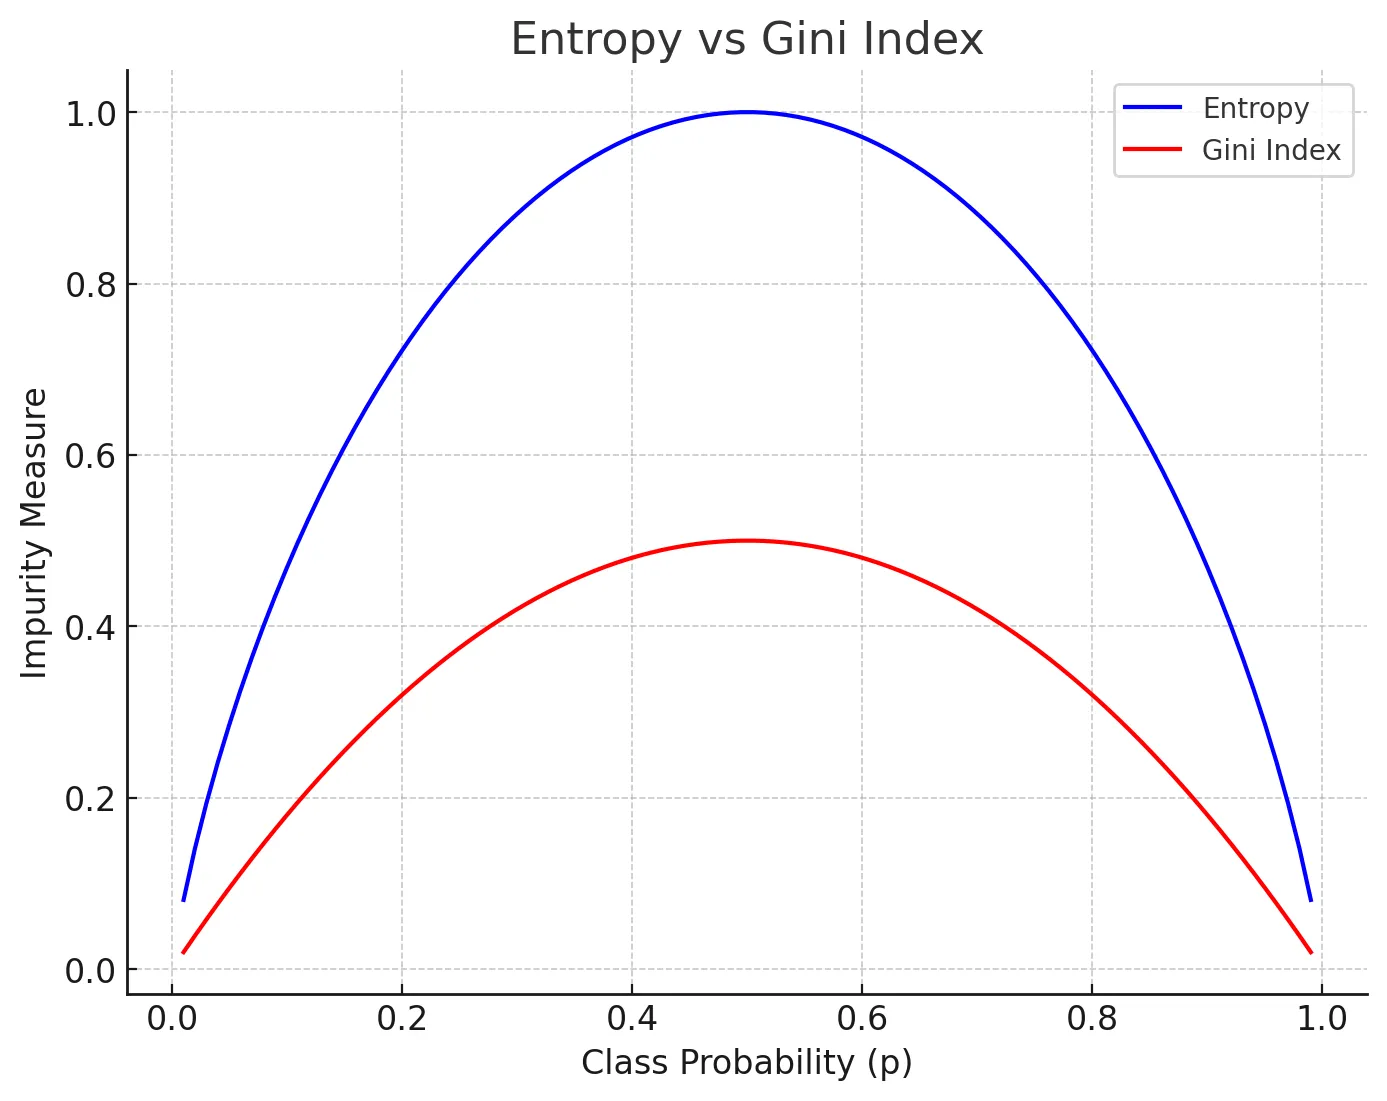

###**엔트로피(Entropy)와 지니 계수(Gini Index) 실생활 사례**

#### **1. 엔트로피(Entropy)**

**예제: 편의점에서 손님이 어떤 음료를 선택할까?**

- 편의점에서 손님이 **콜라(50%)**, **사이다(50%)** 를 고를 확률이 같다면, 어떤 음료를 선택할지 **예측이 어렵다**.
    - 이 경우 **엔트로피(불확실성)가 높음** → **엔트로피 값 ≈ 1**
- 반면, 손님이 **콜라(90%)**, **사이다(10%)** 를 선택한다면?
    - **콜라를 선택할 가능성이 매우 높아 예측이 쉬움** → **엔트로피 값 ≈ 0.47 (낮음)**

**결론:**

- **엔트로피가 높을수록 선택이 랜덤(불확실)하므로, 데이터를 더 정밀하게 분류해야 함**
- 결정 트리는 **엔트로피가 가장 크게 줄어드는(정보 이득이 높은) 기준으로 데이터를 나눔**


#### **2. 지니 계수(Gini Index)**

**예제: 농구팀에서 선수 선발하기**

- 농구팀을 꾸릴 때, **신장(키)에 따라 선수 선발**을 한다고 가정하자
- 만약 **선수 10명 중 5명이 190cm 이상, 5명이 180cm 이하**라면?
    - **불순도가 높음** (팀 구성이 균등하여 선택이 어렵다) → **지니 계수 ≈ 0.5 (최대값)**
- 하지만 **선수 9명이 190cm 이상이고, 1명만 180cm 이하**라면?
    - **대부분 키가 크므로 불순도가 낮다** → **지니 계수 ≈ 0.18 (낮음)**

**결론:**

- **지니 계수가 낮을수록 특정 그룹으로 쉽게 분류할 수 있음**
- 결정 트리는 **지니 계수가 가장 낮아지는 기준으로 데이터를 나눔**

#### **3. 엔트로피 vs 지니 계수 차이**

| **비교 항목** | **엔트로피(Entropy)** | **지니 계수(Gini Index)** |
| --- | --- | --- |
| **개념** | 불확실성을 측정 | 그룹 간 불순도를 측정 |
| **최대값** | 0.5 vs 0.5 (동일 확률일 때) | 0.5 vs 0.5 (동일 확률일 때) |
| **최소값** | 0 (완전히 한쪽으로 치우침) | 0 (완전히 한쪽으로 치우침) |
| **특징** | 더 정밀하게 분류 | 계산이 더 빠름 |
| **사용 예제** | 광고 클릭 여부 예측 | 고객 만족도 그룹 분류 |

#### **4. 실무 적용**

- **엔트로피**: 고객이 구매할 상품을 예측할 때 → **정보 이득(Information Gain)이 높은 기준으로 데이터를 나눔**
- **지니 계수**: 병원에서 질병 유무를 판단할 때 → **빠르고 간결한 계산으로 그룹을 나눔**

💡 **둘 다 불순도를 낮추는 역할을 하지만, 지니 계수는 계산이 더 빠르고, 엔트로피는 좀 더 정밀한 분류를 유도**. 따라서 **실제 프로젝트에서는 두 방법을 비교하여 더 좋은 결과를 내는 방식을 선택하는 것이 중요함**




#### **엔트로피(Entropy)**

- 데이터의 **불확실성(혼잡도, Randomness)** 을 측정하는 값
- 값이 낮을수록 불확실성이 적으며, 하나의 클래스에 가까운 데이터
- 엔트로피가 가장 크게 감소하는 기준으로 데이터를 분할함

$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$

여기서,

- $p_i$ = 클래스 $i$에 속할 확률
- $c$ = 총 클래스 개수

#### **지니 지수(Gini Index)**

- 불순도(Impurity)를 측정하는 값
- 낮을수록 데이터가 특정 클래스에 속할 확률이 높음

$$
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

- **지니 지수가 낮을수록 불순도가 낮으며, 해당 특징을 기준으로 데이터를 나누는 것이 효과적임**
- 다음은 엔트로피와 지니계수를 구하는 파이썬 코드임

In [5]:
import numpy as np

def calculate_gini(labels):
    """
    지니 계수(Gini Index)를 계산하는 함수
    - 공식: Gini = 1 - sum(p_i^2)
    - 값이 낮을수록 한쪽 클래스에 집중된 데이터

    labels: 리스트 형태의 클래스 라벨 (예: [0, 1, 1, 0, ...])
    반환값: 지니 계수 (0~1 사이 값)
    """
    unique_classes, counts = np.unique(labels, return_counts=True)  # 각 클래스의 개수 계산
    probabilities = counts / len(labels)  # 각 클래스의 확률 계산
    gini = 1 - np.sum(probabilities**2)  # 지니 계수 계산
    return gini

def calculate_entropy(labels):
    """
    엔트로피(Entropy)를 계산하는 함수
    - 공식: Entropy = -sum(p_i * log2(p_i))
    - 값이 낮을수록 한쪽 클래스에 집중된 데이터

    labels: 리스트 형태의 클래스 라벨 (예: [0, 1, 1, 0, ...])
    반환값: 엔트로피 값 (0~1 사이 값, 균등할수록 1에 가까움)
    """
    unique_classes, counts = np.unique(labels, return_counts=True)  # 각 클래스의 개수 계산
    probabilities = counts / len(labels)  # 각 클래스의 확률 계산
    entropy = -np.sum(probabilities * np.log2(probabilities))  # 엔트로피 계산
    return entropy

# 예제 데이터 (0: "구매 안 함", 1: "구매")
labels = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]  # 0이 4개, 1이 6개 (비율: 0.4 vs 0.6)

# 지니 계수 및 엔트로피 계산
gini_value = calculate_gini(labels)
entropy_value = calculate_entropy(labels)

# 결과 출력
print(f"지니 계수: {gini_value:.4f}")  # 0.4800 (순도가 낮음)
print(f"엔트로피: {entropy_value:.4f}")  # 0.9709 (데이터가 혼합됨)


지니 계수: 0.4800
엔트로피: 0.9710


### **(2) 가지치기(Pruning)**

- 결정 트리가 과적합(Overfitting) 되는 것을 방지하기 위해 **불필요한 가지(branch)를 제거하는 과정**
- 너무 많은 노드를 사용하면 데이터에 **너무 맞춰진 복잡한 모델(Overfitting)** 이 될 수 있음

#### **사전 가지치기(Pre-Pruning)**

- 트리가 성장하는 동안 **미리 제한 조건을 설정**하여 과적합을 방지
- 예제:
    - 트리의 최대 깊이(Max Depth) 제한
    - 최소 샘플 수(Min Samples Split) 제한

#### **사후 가지치기(Post-Pruning)**

- 먼저 **트리를 최대한 성장**시킨 후, **성능이 저하되지 않는 범위에서 가지를 제거**하는 방법
- 불필요한 노드를 제거하여 모델을 단순화

---

##**3. 결정 트리의 장점과 단점**

### **장점**

1. **해석이 쉬움(Interpretability)**
    - 트리 구조는 직관적이며 사람이 이해하기 쉬움
    - "이 특징이 특정 값보다 크면 A, 작으면 B" 같은 **논리적 규칙 기반으로 분류** 가능
2. **전처리가 거의 필요 없음**
    - 스케일링(Scaling) 필요 없음 (예: Min-Max Scaling, Standardization 불필요)
    - 결측치(Missing Values)와 이상치(Outlier)에 강함
3. **범주형 및 연속형 데이터 모두 처리 가능**
    - 숫자형 변수와 범주형 변수를 모두 다룰 수 있음


### **단점**

1. **과적합(Overfitting) 위험**
    - 트리가 너무 깊어지면 데이터에 너무 맞춰져 새로운 데이터 예측 성능이 낮아질 수 있음
    - 해결 방법: **가지치기(Pruning) 또는 최소 샘플 수 제한 적용**
2. **작은 변화에도 민감(High Variance)**
    - 데이터가 조금만 바뀌어도 트리의 구조가 크게 달라질 수 있음
    - 해결 방법: **랜덤 포레스트(Random Forest)와 같은 앙상블 기법 적용**
3. **비효율적인 분할 가능성**
    - 일부 데이터에서는 **균형이 맞지 않는 트리(Unbalanced Tree)** 가 생성될 수 있음



---

### **지니 계수(Gini Index)와 엔트로피(Entropy)에 의해 결정되는 임계값 예제**

#### (1) 데이터 생성

**특징 값(Feature)과 클래스(Label)로 이루어진 간단한 데이터셋**

특징 값이 **5 이하일 때 클래스 0, 6 이상일 때 클래스 1로 분류**

| Feature | Class |
| --- | --- |
| 1 | 0 |
| 2 | 0 |
| 3 | 0 |
| 4 | 0 |
| 5 | 0 |
| 6 | 1 |
| 7 | 1 |
| 8 | 1 |
| 9 | 1 |
| 10 | 1 |

#### (2) 코드 구형 (지니 계수와 엔트로피 비교)

In [6]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# 간단한 데이터 생성
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])  # 특징값
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # 클래스 값 (0 또는 1)

# 지니 계수를 사용한 결정 트리 모델
tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=1, random_state=42)
tree_gini.fit(X, y)

# 엔트로피를 사용한 결정 트리 모델
tree_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=42)
tree_entropy.fit(X, y)

# 임계값 출력
print("지니 계수를 사용한 분할 기준:", tree_gini.tree_.threshold[0])
print("엔트로피를 사용한 분할 기준:", tree_entropy.tree_.threshold[0])

지니 계수를 사용한 분할 기준: 5.5
엔트로피를 사용한 분할 기준: 5.5


#### (3) 코드 설명

- **X**: 1부터 10까지의 숫자로 이루어진 특징 값.
- **y**: 5 이하일 때 클래스 0, 6 이상일 때 클래스 1로 분류됨.
- `DecisionTreeClassifier(criterion="gini")`: **지니 계수를 사용한 트리 학습**.
- `DecisionTreeClassifier(criterion="entropy")`: **엔트로피를 사용한 트리 학습**.
- `tree.tree_.threshold[0]`: 트리에서 **최초로 데이터를 나눈 임계값(Split Point)을 출력**.

#### (4) 결과 예측

- 지니 계수와 엔트로피는 데이터에서 **가장 최적의 분할 기준(임계값)을 자동으로 계산**한다.

    - 두 방식 모두 **5.5를 기준으로 데이터를 나눔**.
    - 하지만 특정 데이터셋에서는 **다른 임계값이 선택될 수도 있음**.

- **지니 계수와 엔트로피는 결정 트리의 분할 기준을 정하는 핵심 요소**
- **지니 계수는 계산이 빠르고, 엔트로피는 정보 이득을 극대화하는 경향이 있음**
- **둘의 차이는 크지 않지만, 특정 데이터에서는 다르게 작용할 수 있음**



---

##**4. 결정 트리 실습 코드**

모델 정확도: 0.95
분류 보고서:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      0.95      0.95        21

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



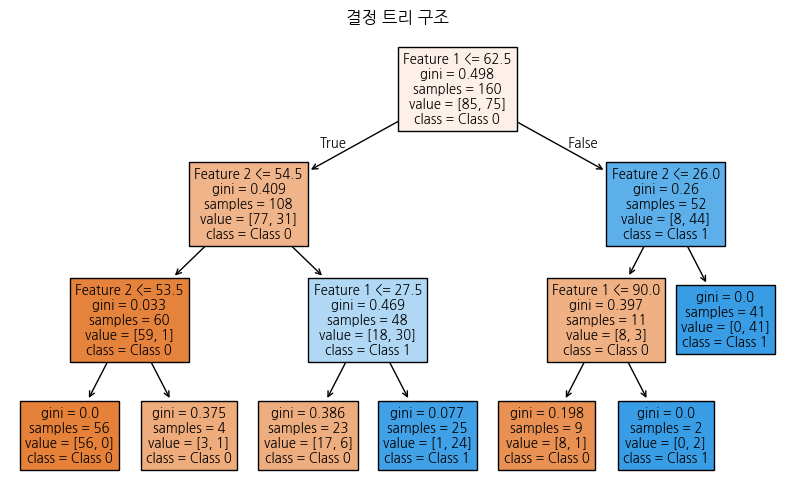

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 데이터 생성
np.random.seed(42)
n_samples = 200
X1 = np.random.randint(1, 100, n_samples)  # Feature 1
X2 = np.random.randint(1, 100, n_samples)  # Feature 2
y = (X1 + X2 > 100).astype(int)  # 단순한 이진 분류 기준

df = pd.DataFrame({"Feature 1": X1, "Feature 2": X2, "Label": y})

# 데이터 분리
X = df[["Feature 1", "Feature 2"]]
y = df["Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 결정 트리 모델 학습
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# 예측 및 평가
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))

# 트리 시각화
plt.figure(figsize=(10, 6))
plot_tree(tree_model, feature_names=["Feature 1", "Feature 2"], class_names=["Class 0", "Class 1"], filled=True)
plt.title("결정 트리 구조")
plt.show()

- 결정 트리는 **특징을 기반으로 데이터를 분할하여 예측하는 모델**이며, **해석이 쉬운 머신러닝 알고리즘**
- 과적합을 방지하기 위해 **가지치기(Pruning)와 트리 깊이 제한(Max Depth)을 조절해야 함**
- **랜덤 포레스트(Random Forest)** 와 같은 앙상블 기법을 사용하면 결정 트리의 단점을 보완할 수 있음
- 다양한 산업에서 **의사 결정 시스템, 신용 평가, 의료 진단, 마케팅 분석** 등 광범위하게 활용됨



---

##**그로스 마케팅(Growth Marketing)에서 의사결정트리를 활용한 예제**

### **예제 1**

### **1) 데이터 시나리오**

한 스타트업이 자사 제품을 광고하는 마케팅 전략을 최적화하려고 합니다. 이를 위해 의사결정트리(Decision Tree)를 활용하여 고객이 제품을 구매할 가능성을 예측하고, 마케팅 캠페인을 효과적으로 설계하려고 합니다.

### **데이터 설명**

고객의 과거 행동 데이터를 수집하여, 특정 마케팅 캠페인에 대한 반응(구매 여부)을 예측하는 모델을 만듭니다.

| 변수명 | 설명 | 예시 데이터 |
| --- | --- | --- |
| **방문 빈도(Frequency)** | 최근 한 달 동안 웹사이트 방문 횟수 | 3, 10, 5, ... |
| **평균 구매 금액(Avg_Purchase_Amount)** | 고객이 과거에 평균적으로 지출한 금액 | 30, 120, 80, ... |
| **이메일 캠페인 반응 여부(Email_Response)** | 이메일 마케팅에 반응했는지 여부 (1: 예, 0: 아니오) | 1, 0, 1, ... |
| **소셜 미디어 활동(Social_Media_Activity)** | 소셜 미디어에서 브랜드 콘텐츠와 상호작용한 횟수 | 2, 8, 4, ... |
| **구매 여부(Purchase)** | 제품을 구매했는지 여부 (1: 구매, 0: 구매 안 함) | 1, 0, 1, ... |

### **2) 모델의 목적**

이 의사결정트리 모델의 목적은:

1. 고객이 제품을 구매할 가능성이 높은지 예측
2. 마케팅 비용을 효율적으로 사용하여 잠재 고객(Target Audience)을 선별
3. 가장 효과적인 마케팅 채널(예: 이메일, 소셜 미디어)을 파악
4. 마케팅 전략을 자동화하여 개인화된 광고 제공

### **3) 파이썬 코드 (의사결정트리 모델 구축 및 시각화)**

이제 **의사결정트리를 이용하여 고객의 구매 여부를 예측하는 모델을 구현**하겠습니다.

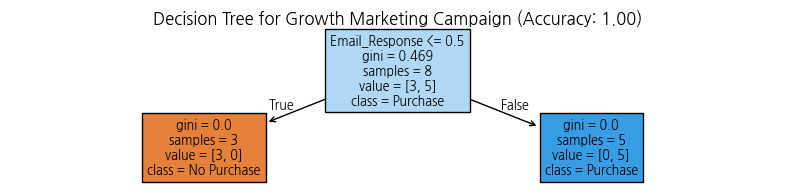

예측 결과: 구매할 가능성이 높음


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. 가상의 고객 데이터 생성 (하드코딩된 값 사용)
data = {
    "Frequency": [3, 10, 5, 8, 1, 12, 4, 7, 6, 2],
    "Avg_Purchase_Amount": [30, 120, 80, 150, 10, 200, 50, 100, 90, 20],
    "Email_Response": [1, 0, 1, 1, 0, 1, 0, 1, 1, 0],
    "Social_Media_Activity": [2, 8, 4, 7, 0, 10, 3, 6, 5, 1],
    "Purchase": [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]  # 타겟 변수 (1: 구매, 0: 구매 안 함)
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# 2. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Purchase"])  # 독립변수
y = df["Purchase"]  # 종속변수 (목표 예측값)

# 3. 데이터 분할 (훈련 데이터 80%, 테스트 데이터 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 의사결정트리 모델 학습
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 5. 모델 예측
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 6. 결정 트리 시각화
fig, ax = plt.subplots(figsize=(10, 2))
plot_tree(dt_model, feature_names=X.columns, class_names=["No Purchase", "Purchase"], filled=True, ax=ax)
plt.title(f"Decision Tree for Growth Marketing Campaign (Accuracy: {accuracy:.2f})")
plt.show()

# 7. 고객 데이터 입력 후 구매 예측 함수 (Feature Name 문제 해결)
def predict_purchase(Frequency, Avg_Purchase_Amount, Email_Response, Social_Media_Activity):
    """
    입력한 고객 데이터를 기반으로 구매 여부를 예측하는 함수
    """
    # 입력 데이터를 DataFrame 형태로 변환하여 Feature Names 유지
    input_data = pd.DataFrame([[Frequency, Avg_Purchase_Amount, Email_Response, Social_Media_Activity]],
                              columns=X.columns)

    prediction = dt_model.predict(input_data)
    return "구매할 가능성이 높음" if prediction[0] == 1 else "구매하지 않을 가능성이 높음"

# 8. 예제 입력 데이터 (사용자가 예측하고 싶은 값)
example_input = {
    "Frequency": 5,  # 웹사이트 방문 횟수
    "Avg_Purchase_Amount": 90,  # 평균 구매 금액
    "Email_Response": 1,  # 이메일 캠페인 반응 여부 (1: 반응, 0: 반응 없음)
    "Social_Media_Activity": 4  # 소셜 미디어 활동 횟수
}

# 9. 예측 실행
prediction_result = predict_purchase(**example_input)
print(f"예측 결과: {prediction_result}")


### **예제 2**

### **1) 데이터 시나리오**

한 SaaS(Software as a Service) 기업이 자사의 B2B 고객이 **유료 플랜으로 전환할 가능성**을 예측하고자 한다.

특정 고객이 무료 체험판(Trial) 이후 유료 플랜을 구매할 가능성이 있는지를 분석하기 위해 고객 행동 데이터를 수집한다.

### **데이터 변수**

- **사용 일수(Days_Active)**: 사용자가 무료 체험판을 사용한 일수
- **기능 활용 개수(Features_Used)**: 사용자가 활성화한 기능 개수
- **고객 지원 요청 횟수(Support_Tickets)**: 고객이 요청한 지원 티켓 수
- **팀원 추가 여부(Added_Team_Member)**: 팀원을 추가했는지 여부 (1: 예, 0: 아니오)
- **유료 플랜 전환 여부(Upgrade)**: 고객이 유료 플랜으로 전환했는지 여부 (목표 변수, 1: 전환, 0: 유지)

### **2) 모델의 목적**

1. **무료 체험판 사용자의 유료 플랜 전환 가능성 예측**
2. **고객 행동을 분석하여 전환율을 높일 전략 설계**
3. **전환 가능성이 높은 고객에게 맞춤형 제안 제공**

### **3) 파이썬 코드 (의사결정트리 모델 구축 및 예측)**

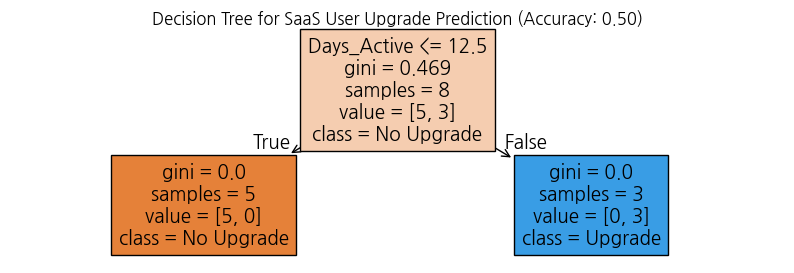

예측 결과: 무료 체험 유지 가능성이 높음


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. 가상의 고객 데이터 생성
data = {
    "Days_Active": [5, 20, 10, 15, 3, 25, 8, 18, 12, 7],
    "Features_Used": [2, 8, 5, 7, 1, 10, 3, 6, 6, 2],
    "Support_Tickets": [0, 2, 1, 3, 0, 4, 0, 2, 1, 0],
    "Added_Team_Member": [0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    "Upgrade": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 유료 플랜 전환, 0: 무료 체험 유지
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Upgrade"])
y = df["Upgrade"]

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 의사결정트리 모델 학습
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 7. 결정 트리 시각화
fig, ax = plt.subplots(figsize=(10, 3))
plot_tree(dt_model, feature_names=X.columns, class_names=["No Upgrade", "Upgrade"], filled=True, ax=ax)
plt.title(f"Decision Tree for SaaS User Upgrade Prediction (Accuracy: {accuracy:.2f})")
plt.show()

# 8. 유료 플랜 전환 예측 함수
def predict_upgrade(Days_Active, Features_Used, Support_Tickets, Added_Team_Member):
    input_data = pd.DataFrame([[Days_Active, Features_Used, Support_Tickets, Added_Team_Member]],
                              columns=X.columns)
    prediction = dt_model.predict(input_data)
    return "유료 플랜으로 전환할 가능성이 높음" if prediction[0] == 1 else "무료 체험 유지 가능성이 높음"

# 9. 예제 입력 데이터 및 예측 실행
example_input = {"Days_Active": 10, "Features_Used": 5, "Support_Tickets": 1, "Added_Team_Member": 1}
prediction_result = predict_upgrade(**example_input)
print(f"예측 결과: {prediction_result}")


### **예제 3: 이메일 마케팅 캠페인 반응 예측**


### **1) 데이터 시나리오**

한 전자상거래(E-commerce) 기업이 이메일 마케팅 캠페인에 대한 고객 반응을 분석하고자 한다.

특정 고객이 이메일을 열어보고 클릭(참여)할 가능성이 있는지를 예측하기 위해 고객 데이터를 수집한다.

### **데이터 변수**

- **이메일 발송 횟수(Emails_Sent)**: 해당 고객에게 보낸 이메일 수
- **과거 이메일 클릭 횟수(Email_Clicks)**: 고객이 과거에 클릭한 이메일 수
- **웹사이트 방문 빈도(Website_Visits)**: 고객이 최근 한 달 동안 웹사이트를 방문한 횟수
- **할인 코드 사용 여부(Used_Discount_Code)**: 고객이 이전 구매 시 할인 코드를 사용했는지 여부 (1: 예, 0: 아니오)
- **이메일 참여 여부(Clicked_Email)**: 고객이 이메일을 클릭했는지 여부 (목표 변수, 1: 클릭, 0: 클릭 안 함)


### **2) 모델의 목적**

1. **이메일 캠페인에서 고객의 클릭 가능성을 예측**
2. **이메일을 효과적으로 타겟팅하여 캠페인 성과 향상**
3. **할인 코드, 방문 빈도 등의 요소가 클릭에 미치는 영향 분석**


### **3) 파이썬 코드 (의사결정트리 모델 구축 및 예측)**

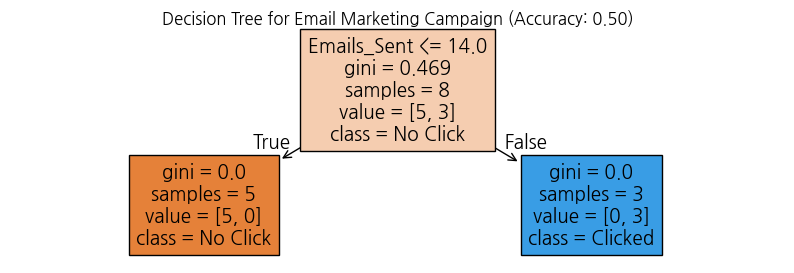

예측 결과: 이메일을 클릭하지 않을 가능성이 높음


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. 가상의 고객 데이터 생성
data = {
    "Emails_Sent": [5, 15, 10, 20, 3, 25, 8, 18, 12, 7],
    "Email_Clicks": [1, 5, 2, 7, 0, 10, 1, 6, 4, 2],
    "Website_Visits": [3, 10, 5, 12, 1, 15, 4, 8, 6, 3],
    "Used_Discount_Code": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Clicked_Email": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 클릭, 0: 클릭 안 함
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Clicked_Email"])
y = df["Clicked_Email"]

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 의사결정트리 모델 학습
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 7. 결정 트리 시각화
fig, ax = plt.subplots(figsize=(10, 3))
plot_tree(dt_model, feature_names=X.columns, class_names=["No Click", "Clicked"], filled=True, ax=ax)
plt.title(f"Decision Tree for Email Marketing Campaign (Accuracy: {accuracy:.2f})")
plt.show()

# 8. 이메일 클릭 예측 함수
def predict_email_click(Emails_Sent, Email_Clicks, Website_Visits, Used_Discount_Code):
    input_data = pd.DataFrame([[Emails_Sent, Email_Clicks, Website_Visits, Used_Discount_Code]],
                              columns=X.columns)
    prediction = dt_model.predict(input_data)
    return "이메일을 클릭할 가능성이 높음" if prediction[0] == 1 else "이메일을 클릭하지 않을 가능성이 높음"

# 9. 예제 입력 데이터 및 예측 실행
example_input = {"Emails_Sent": 10, "Email_Clicks": 2, "Website_Visits": 5, "Used_Discount_Code": 0}
prediction_result = predict_email_click(**example_input)
print(f"예측 결과: {prediction_result}")


### **예제 4: 모바일 앱 사용자의 유료 결제 예측**


### **1) 데이터 시나리오**

한 모바일 앱 서비스에서 사용자의 유료 결제 가능성을 예측하고자 한다.

무료 사용자들이 앱을 얼마나 사용하고 어떤 행동을 하는지 분석하여 **유료 결제 가능성이 높은 사용자**를 찾는다.

### **데이터 변수**

- **앱 사용 일수(App_Usage_Days)**: 사용자가 앱을 사용한 총 일수
- **게임/콘텐츠 이용 횟수(Feature_Usage_Count)**: 사용자가 특정 프리미엄 기능을 사용한 횟수
- **푸시 알림 클릭 여부(Clicked_Push_Notification)**: 사용자가 푸시 알림을 클릭했는지 여부 (1: 예, 0: 아니오)
- **친구 초대 여부(Invited_Friends)**: 사용자가 친구를 초대했는지 여부 (1: 예, 0: 아니오)
- **유료 결제 여부(Paid_User)**: 사용자가 유료 결제를 했는지 여부 (목표 변수, 1: 결제, 0: 결제 안 함)


### **2) 모델의 목적**

1. **무료 사용자 중 유료 결제 가능성이 높은 고객 예측**
2. **프리미엄 기능 이용량과 유료 전환율 간의 관계 분석**
3. **고객 행동 데이터 기반 맞춤형 결제 유도 전략 수립**

### **3) 파이썬 코드 (의사결정트리 모델 구축 및 예측)**

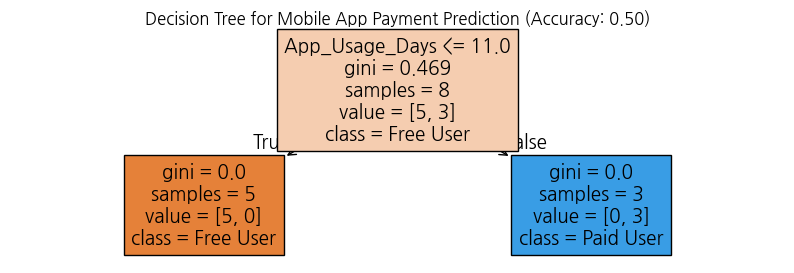

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. 가상의 고객 데이터 생성
data = {
    "App_Usage_Days": [3, 20, 7, 15, 2, 30, 6, 18, 10, 5],
    "Feature_Usage_Count": [1, 10, 3, 8, 0, 15, 2, 7, 5, 1],
    "Clicked_Push_Notification": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Invited_Friends": [0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    "Paid_User": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 유료 결제, 0: 무료 사용자
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Paid_User"])
y = df["Paid_User"]

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 의사결정트리 모델 학습
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 7. 결정 트리 시각화
fig, ax = plt.subplots(figsize=(10, 3))
plot_tree(dt_model, feature_names=X.columns, class_names=["Free User", "Paid User"], filled=True, ax=ax)
plt.title(f"Decision Tree for Mobile App Payment Prediction (Accuracy: {accuracy:.2f})")
plt.show()

# 8. 유료 결제 예측 함수
def predict_payment(App_Usage_Days, Feature_Usage_Count, Clicked_Push_Notification, Invited_Friends):
    input_data = pd.DataFrame([[App_Usage_Days, Feature_Usage_Count, Clicked_Push_Notification, Invited_Friends]],
                              columns=X.columns)
    prediction = dt_model.predict(input_data)
    return "유료 결제 가능성이 높음" if prediction[0] == 1 else "무료 사용자 유지 가능성이 높음"


### **예제 5: 주어진 데이터셋을 이용해 특정 지역의 매출건수예시.**

“서울시 상권분석 데이터.csv” 데이터셋을 이용해 “사가정역”에서의 “당월매출건수”를 예측하는 회귀 코드 예시 입니다. ^^

Mean Absolute Error (MAE): 4538.25
R² Score: 0.98


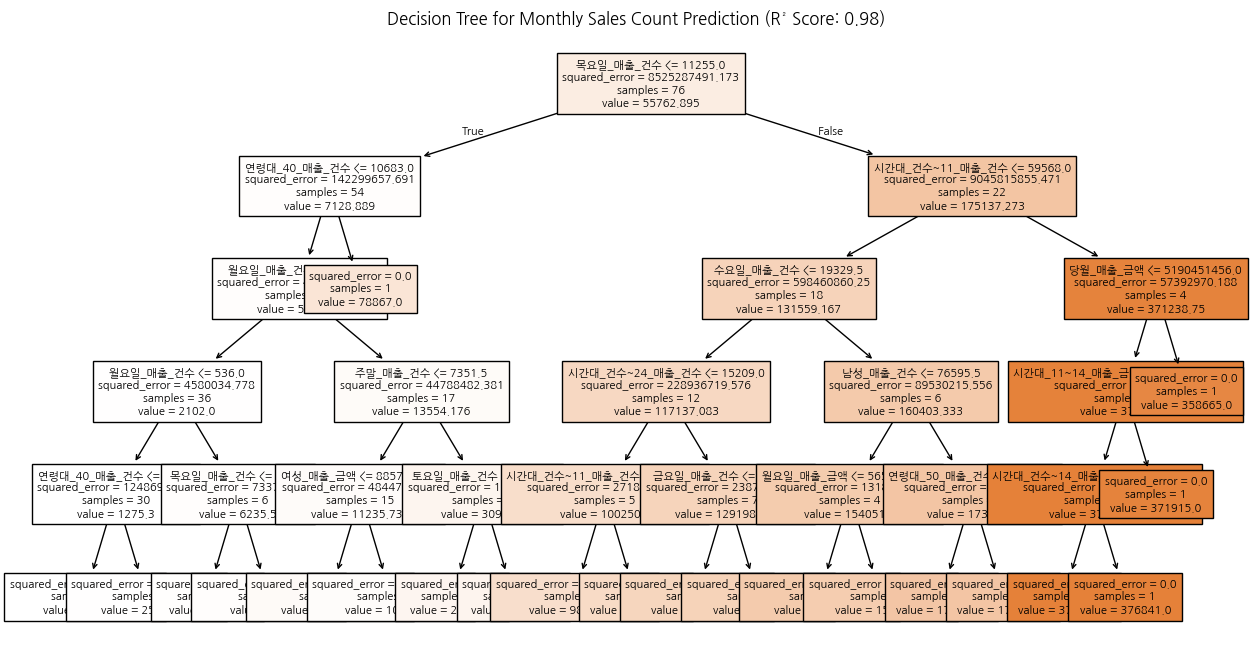

예상 당월 매출 건수: 511 건


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CSV 파일 로드
df = pd.read_csv("서울시상권분석데이터.csv", encoding='utf-8-sig')

# 2. "사가정역" 데이터 필터링
df = df[df["상권_코드_명"] == "사가정역"]

# 3. 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]  # 분석에 필요 없는 컬럼 제거
df = df.drop(columns=drop_columns)

# 4. 결측값 제거
df = df.dropna()

# 5. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["당월_매출_건수"])  # 입력 변수 (매출 건수를 예측해야 하므로 제외)
y = df["당월_매출_건수"]  # 타겟 변수 (예측 대상)

# 6. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 결정트리 회귀 모델 학습
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 8. 모델 예측 및 평가
y_pred = dt_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for Monthly Sales Count Prediction (R² Score: {r2:.2f})")
plt.show()

# 10. 예측 함수
def predict_sales_count(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = dt_model.predict(input_data)
    return f"예상 당월 매출 건수: {prediction[0]:,.0f} 건"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_count(sample_input))




---



### 어쩌다 마주친 문제

문제 1.  다음의 데이터셋을 이용하여 발달상권의 당월 매출금액을 예측하는 예측모델을 개발하세요

- 결정트리 알고리즘을 사용해서 예측모델을 만드세요.
- 예측정확도를 90% 이상 충족하고
- 위 예측모델을 만들기 위한 독립변수를 제시하세요.

[서울시 상권분석 데이터.csv](attachment:4fa79ddc-0f0d-4119-be17-0cd3869159ad:서울시_상권분석_데이터.csv)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv("서울시상권분석데이터.csv", encoding='utf-8-sig')
display(df)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20221,D,발달상권,3120068,사가정역,CS200016,당구장,6207432.0,362,3619902.0,...,163,82,347,15,0,42,38,45,150,87
1,20221,A,골목상권,3110316,숭곡초등학교,CS300033,철물점,11755885.0,69,11755885.0,...,0,0,69,0,0,0,0,69,0,0
2,20221,R,전통시장,3130032,인현시장,CS200037,노래방,49610438.0,339,37313834.0,...,255,84,296,0,0,0,169,0,127,0
3,20221,D,발달상권,3120105,상수역(홍대),CS300001,슈퍼마켓,4091445.0,236,2589971.0,...,148,0,0,236,0,148,88,0,0,0
4,20221,A,골목상권,3110431,상계역,CS300001,슈퍼마켓,1828934.0,16,1828934.0,...,6,0,0,16,0,0,0,0,10,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83568,20224,R,전통시장,3130051,동화동 골목형상점가,CS100010,커피-음료,74566607.0,11618,46002960.0,...,811,56,4239,7016,41,1539,2107,2831,2696,2037
83569,20224,A,골목상권,3110121,한양대역 4번,CS100010,커피-음료,496341232.0,74976,343713652.0,...,22056,9747,37372,37498,6632,45799,6409,5767,9168,1094
83570,20224,A,골목상권,3110163,성자초등학교,CS100010,커피-음료,60999234.0,10668,39994099.0,...,2205,349,5054,5440,212,2459,2483,2900,1459,980
83571,20224,A,골목상권,3110110,상왕십리역 6번,CS100010,커피-음료,35826724.0,4681,17309483.0,...,361,0,1811,2870,0,1966,1784,672,155,104


In [36]:
df_development = df[df["상권_구분_코드_명"] == "발달상권"]
display(df_development)
print(df_development.info())

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20221,D,발달상권,3120068,사가정역,CS200016,당구장,6.207432e+06,362,3.619902e+06,...,163,82,347,15,0,42,38,45,150,87
3,20221,D,발달상권,3120105,상수역(홍대),CS300001,슈퍼마켓,4.091445e+06,236,2.589971e+06,...,148,0,0,236,0,148,88,0,0,0
6,20221,D,발달상권,3120078,미아사거리역,CS200016,당구장,2.078195e+07,1120,1.262849e+07,...,768,101,845,275,5,179,157,429,257,94
7,20221,D,발달상권,3120079,창동역,CS200016,당구장,1.349612e+08,8944,8.803607e+07,...,5178,1861,8423,513,142,384,227,2345,4616,1221
8,20221,D,발달상권,3120086,태릉입구역,CS200016,당구장,3.355910e+07,1700,2.508250e+07,...,1062,277,1587,113,21,100,177,42,779,581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83558,20224,D,발달상권,3120165,서래마을카페거리(서래마을),CS100009,호프-간이주점,1.483974e+09,16276,1.055898e+09,...,3701,7109,8462,5583,149,2984,4436,3560,1981,935
83560,20224,D,발달상권,3120010,원남동사거리,CS100010,커피-음료,2.973566e+08,51517,2.907553e+08,...,1077,0,22671,22810,33,11980,17042,10216,5060,1149
83563,20224,D,발달상권,3120024,회현역,CS100010,커피-음료,6.633601e+08,45590,5.590025e+08,...,5909,2594,19218,21788,187,8608,12008,8376,6452,5372
83566,20224,D,발달상권,3120056,구의역,CS100010,커피-음료,7.172703e+08,111612,5.152000e+08,...,27248,6013,52597,56542,1942,38013,30881,18662,14280,5358


<class 'pandas.core.frame.DataFrame'>
Index: 29142 entries, 0 to 83572
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   기준_년분기_코드        29142 non-null  int64  
 1   상권_구분_코드         29142 non-null  object 
 2   상권_구분_코드_명       29142 non-null  object 
 3   상권_코드            29142 non-null  int64  
 4   상권_코드_명          29142 non-null  object 
 5   서비스_업종_코드        29142 non-null  object 
 6   서비스_업종_코드_명      29142 non-null  object 
 7   당월_매출_금액         29142 non-null  float64
 8   당월_매출_건수         29142 non-null  int64  
 9   주중_매출_금액         29142 non-null  float64
 10  주말_매출_금액         29142 non-null  float64
 11  월요일_매출_금액        29142 non-null  float64
 12  화요일_매출_금액        29142 non-null  float64
 13  수요일_매출_금액        29142 non-null  float64
 14  목요일_매출_금액        29142 non-null  float64
 15  금요일_매출_금액        29142 non-null  float64
 16  토요일_매출_금액        29142 non-null  float64
 17  일요일_매출_금액        

Mean Absolute Error (MAE): 452739182.90
R² Score: 0.98


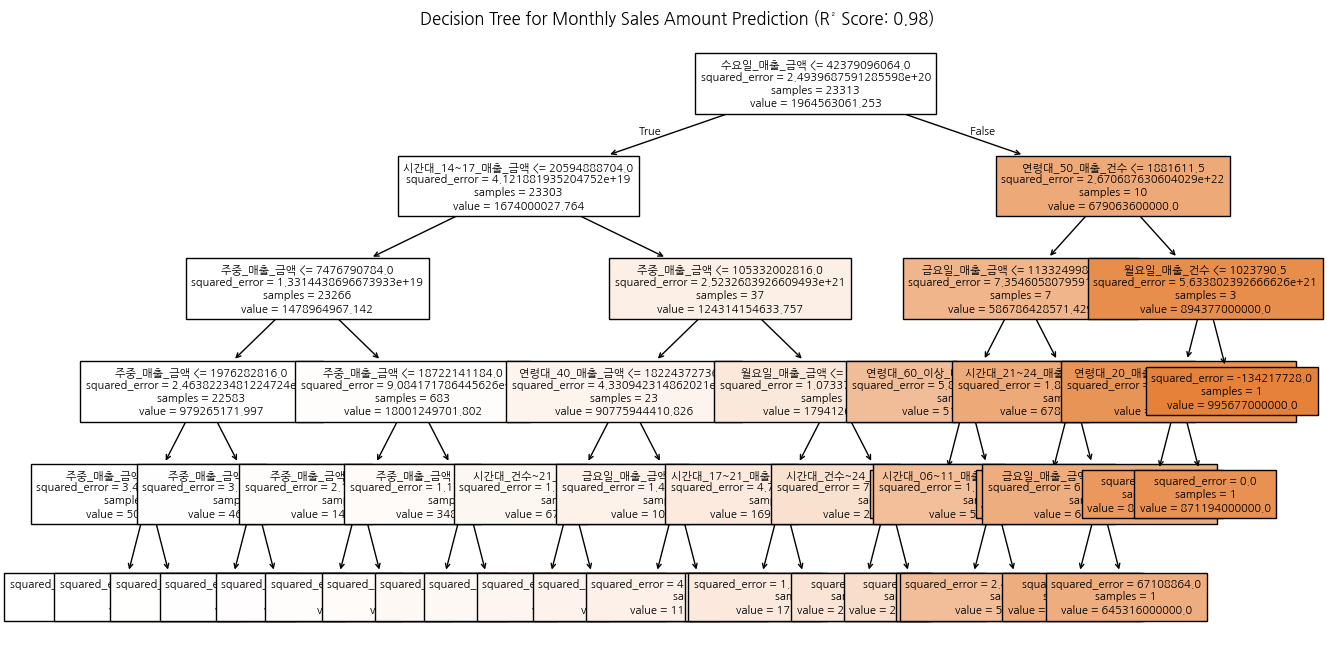

예상 당월 매출 금액: 253,027,303 원


In [37]:
# 분석에 필요 없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]
df_development = df_development.drop(columns=drop_columns)

# 결측값 제거
df_development = df_development.dropna()

# 입력(X)과 타겟(y) 분리
X = df_development.drop(columns=["당월_매출_금액"])
y = df_development["당월_매출_금액"]

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정트리 모델 학습
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 모델 예측 및 정확도 평가
y_pred = dt_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for Monthly Sales Amount Prediction (R² Score: {r2:.2f})")
plt.show()

# 예측 함수
def predict_sales_amount(data_input):
  input_data = pd.DataFrame([data_input], columns=X.columns)
  prediction = dt_model.predict(input_data)
  return f"예상 당월 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values # 첫번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

문제 2. 미아사거리의 주중 매출액을 예측하는 모델을 개발하세요

- 조건은 1번과 같습니다.

In [40]:
df_mia = df[df['상권_코드_명'] == "미아사거리"]
display(df_mia)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
764,20221,D,발달상권,3120073,미아사거리,CS100001,한식음식점,1.086388e+09,37208,720318025.0,...,9430,1176,21339,13746,144,1983,4717,7685,10078,10478
1197,20221,D,발달상권,3120073,미아사거리,CS200006,일반의원,1.292054e+08,3216,109656430.0,...,312,0,563,2653,0,468,630,659,944,515
2225,20221,D,발달상권,3120073,미아사거리,CS100008,분식전문점,2.397262e+07,2704,18079397.0,...,325,0,1017,1621,0,372,747,836,539,143
4252,20221,D,발달상권,3120073,미아사거리,CS300011,일반의류,2.233063e+07,314,20183828.0,...,50,0,30,284,0,0,20,50,127,117
4343,20221,D,발달상권,3120073,미아사거리,CS300019,의료기기,1.216789e+09,4400,802901626.0,...,468,0,2245,2155,0,116,395,469,884,2536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76022,20224,D,발달상권,3120073,미아사거리,CS200005,스포츠 강습,7.824133e+06,42,7824133.0,...,18,6,36,6,0,0,0,36,6,0
80178,20224,D,발달상권,3120073,미아사거리,CS300011,일반의류,6.940336e+07,1108,59982929.0,...,118,0,127,981,0,10,68,157,294,579
81948,20224,D,발달상권,3120073,미아사거리,CS200006,일반의원,1.476339e+08,3736,118327218.0,...,351,0,663,3073,9,464,634,945,947,737
82249,20224,D,발달상권,3120073,미아사거리,CS200028,미용실,2.273454e+08,6219,147280316.0,...,2104,28,3585,2634,78,618,971,2091,1672,789


Mean Absolute Error (MAE): 60920672.48
R² Score: 0.99


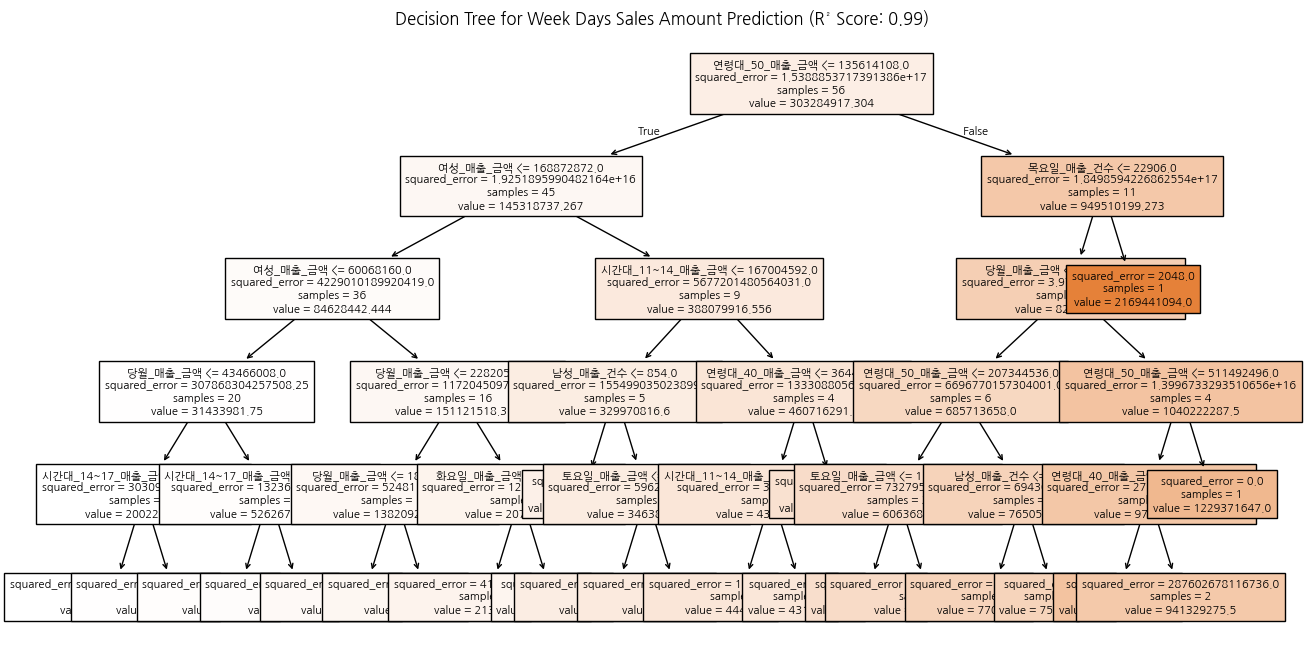

예상 주중 매출 금액: 753,275,286 원


In [41]:
# 분석에 필요 없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]
df_mia = df_mia.drop(columns=drop_columns)

# 결측값 제거
df_mia = df_mia.dropna()

# 입력(X)과 타겟(y) 분리
X = df_mia.drop(columns=["주중_매출_금액"])
y = df_mia["주중_매출_금액"]

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정트리 모델 학습
dt_model2 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model2.fit(X_train, y_train)

# 모델 예측 및 정확도 평가
y_pred = dt_model2.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model2, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for Week Days Sales Amount Prediction (R² Score: {r2:.2f})")
plt.show()

# 예측 함수
def predict_sales_amount(data_input):
  input_data = pd.DataFrame([data_input], columns=X.columns)
  prediction = dt_model2.predict(input_data)
  return f"예상 주중 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values # 첫번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

문제 3. 특정상권내 특정 조건 매출 예측

- 발달상권 내 당구장의 시간대_21~24_매출_금액 예측
- 골목상권 내 철물점의 시간대_06~11_매출_건수 예측
- 발달상권 내 당구장의 연령대_20_매출_금액 예측

In [48]:
# 발달상권 내 당구장
df_pool = df[(df["상권_구분_코드_명"] == "발달상권") & (df["서비스_업종_코드_명"] == "당구장")]
display(df_pool)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20221,D,발달상권,3120068,사가정역,CS200016,당구장,6207432.0,362,3619902.0,...,163,82,347,15,0,42,38,45,150,87
6,20221,D,발달상권,3120078,미아사거리역,CS200016,당구장,20781954.0,1120,12628493.0,...,768,101,845,275,5,179,157,429,257,94
7,20221,D,발달상권,3120079,창동역,CS200016,당구장,134961191.0,8944,88036070.0,...,5178,1861,8423,513,142,384,227,2345,4616,1221
8,20221,D,발달상권,3120086,태릉입구역,CS200016,당구장,33559097.0,1700,25082503.0,...,1062,277,1587,113,21,100,177,42,779,581
9,20221,D,발달상권,3120153,노량진역(노량진),CS200016,당구장,67354277.0,1660,58295630.0,...,938,179,1462,187,36,344,404,400,347,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82034,20224,D,발달상권,3120111,목동사거리,CS200016,당구장,76554680.0,2380,56305228.0,...,641,645,2036,344,61,160,463,360,880,456
82035,20224,D,발달상권,3120094,"신촌역(신촌역, 신촌로터리)",CS200016,당구장,78930043.0,5000,52686891.0,...,2239,1086,4247,665,200,1266,650,1199,983,615
82036,20224,D,발달상권,3120106,마포역,CS200016,당구장,55652066.0,2867,37739928.0,...,1172,633,2592,190,21,32,316,873,1107,433
82037,20224,D,발달상권,3120187,신논현역,CS200016,당구장,126869537.0,4675,87788990.0,...,2165,765,2862,1686,48,1914,1070,573,441,502


Mean Absolute Error (MAE): 6075259.87
R² Score: 0.88


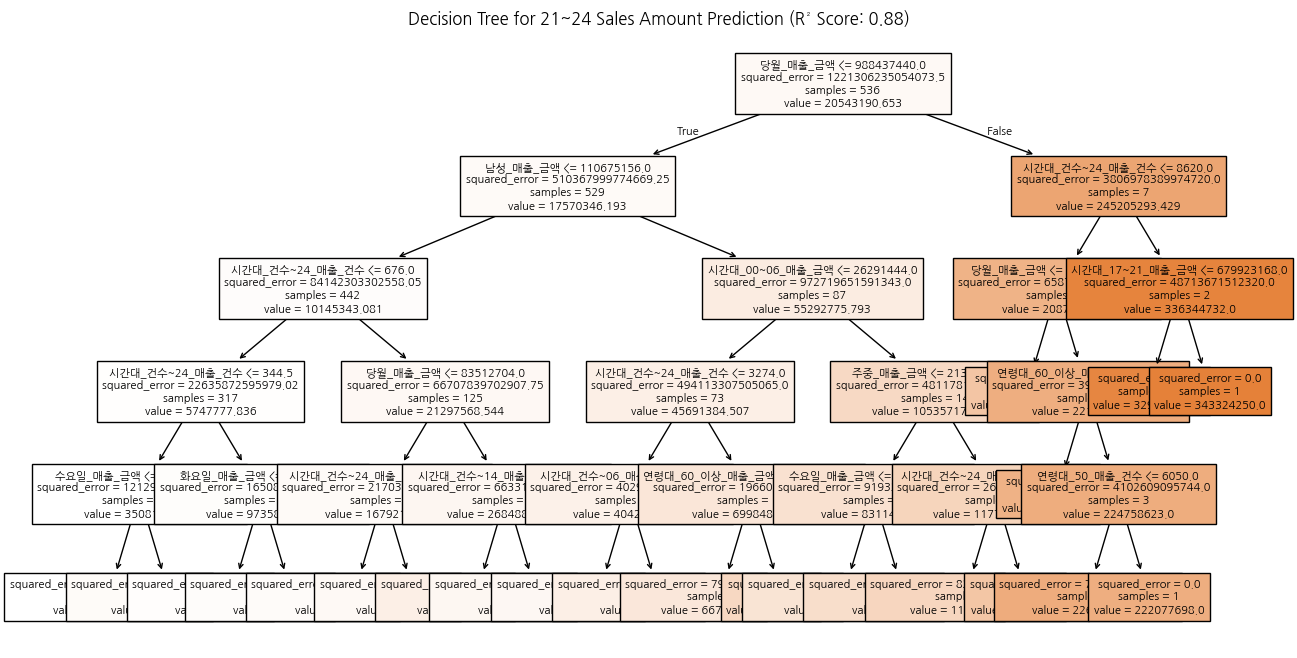

예상 21~24시 매출 금액: 3,158,067 원


In [49]:
# 분석에 필요 없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]
df_pool = df_pool.drop(columns=drop_columns)

# 결측값 제거
df_pool = df_pool.dropna()

# 입력(X)과 타겟(y) 분리
X = df_pool.drop(columns=["시간대_21~24_매출_금액"])
y = df_pool["시간대_21~24_매출_금액"]

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정트리 모델 학습
dt_model3 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model3.fit(X_train, y_train)

# 모델 예측 및 정확도 평가
y_pred = dt_model3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model3, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for 21~24 Sales Amount Prediction (R² Score: {r2:.2f})")
plt.show()

# 예측 함수
def predict_sales_amount(data_input):
  input_data = pd.DataFrame([data_input], columns=X.columns)
  prediction = dt_model3.predict(input_data)
  return f"예상 21~24시 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values # 첫번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

Mean Absolute Error (MAE): 6257336.98
R² Score: 0.86


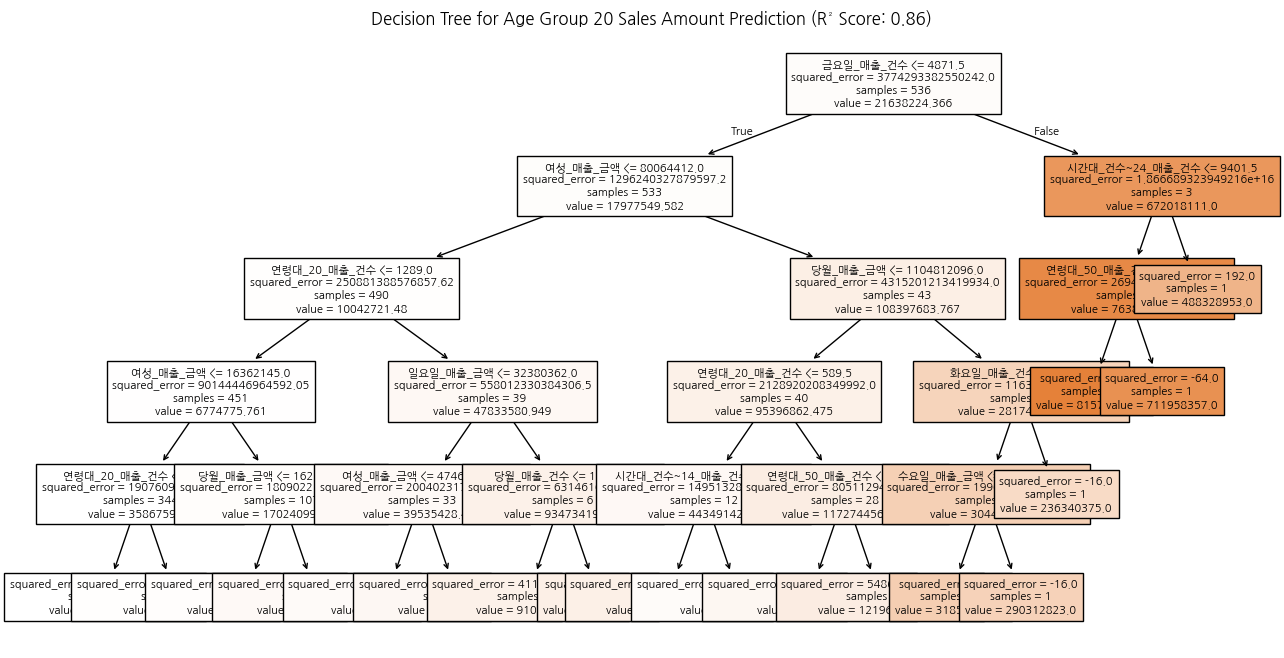

예상 20대 매출 금액: 1,838,805 원


In [57]:
# 입력(X)과 타겟(y) 분리
X = df_pool.drop(columns=["연령대_20_매출_금액"])
y = df_pool["연령대_20_매출_금액"]

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정트리 모델 학습
dt_model4 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model4.fit(X_train, y_train)

# 모델 예측 및 정확도 평가
y_pred = dt_model4.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model4, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for Age Group 20 Sales Amount Prediction (R² Score: {r2:.2f})")
plt.show()

# 예측 함수
def predict_sales_amount(data_input):
  input_data = pd.DataFrame([data_input], columns=X.columns)
  prediction = dt_model4.predict(input_data)
  return f"예상 20대 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values # 첫번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

In [55]:
# 골목상권 내 철물점
df_hardware = df[(df["상권_구분_코드_명"] == "골목상권") & (df["서비스_업종_코드_명"] == "철물점")]
display(df_hardware)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
1,20221,A,골목상권,3110316,숭곡초등학교,CS300033,철물점,11755885.0,69,11755885.0,...,0,0,69,0,0,0,0,69,0,0
653,20221,A,골목상권,3110229,장평중학교,CS300033,철물점,286597528.0,7376,256362149.0,...,819,0,4371,547,0,365,774,683,1685,1411
654,20221,A,골목상권,3110297,경동고등학교,CS300033,철물점,25793100.0,1690,21671070.0,...,114,0,922,447,0,72,384,249,508,155
656,20221,A,골목상권,3110654,까치산역 4번,CS300033,철물점,5644812.0,258,3433076.0,...,54,0,178,72,0,9,27,45,89,80
658,20221,A,골목상권,3110600,신월7동주민센터,CS300033,철물점,10359726.0,876,8719377.0,...,118,0,503,288,0,32,246,166,192,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83461,20224,A,골목상권,3111066,암사동성당(효정하나플러스아파트),CS300033,철물점,64568037.0,2284,56273872.0,...,864,0,1197,1031,0,114,343,973,171,628
83462,20224,A,골목상권,3111006,석촌고분역 1번,CS300033,철물점,932629527.0,24735,754325887.0,...,7729,0,11374,9496,0,1657,2319,3754,6294,6847
83463,20224,A,골목상권,3111073,둔촌동역 1번(한산중학교),CS300033,철물점,451793760.0,2724,348214235.0,...,191,0,1459,917,0,366,353,602,578,478
83464,20224,A,골목상권,3111085,묘곡초등학교(고덕아이파크아파트),CS300033,철물점,11818288.0,811,8886439.0,...,64,0,364,121,0,32,105,88,105,155


Mean Absolute Error (MAE): 154.06
R² Score: 0.90


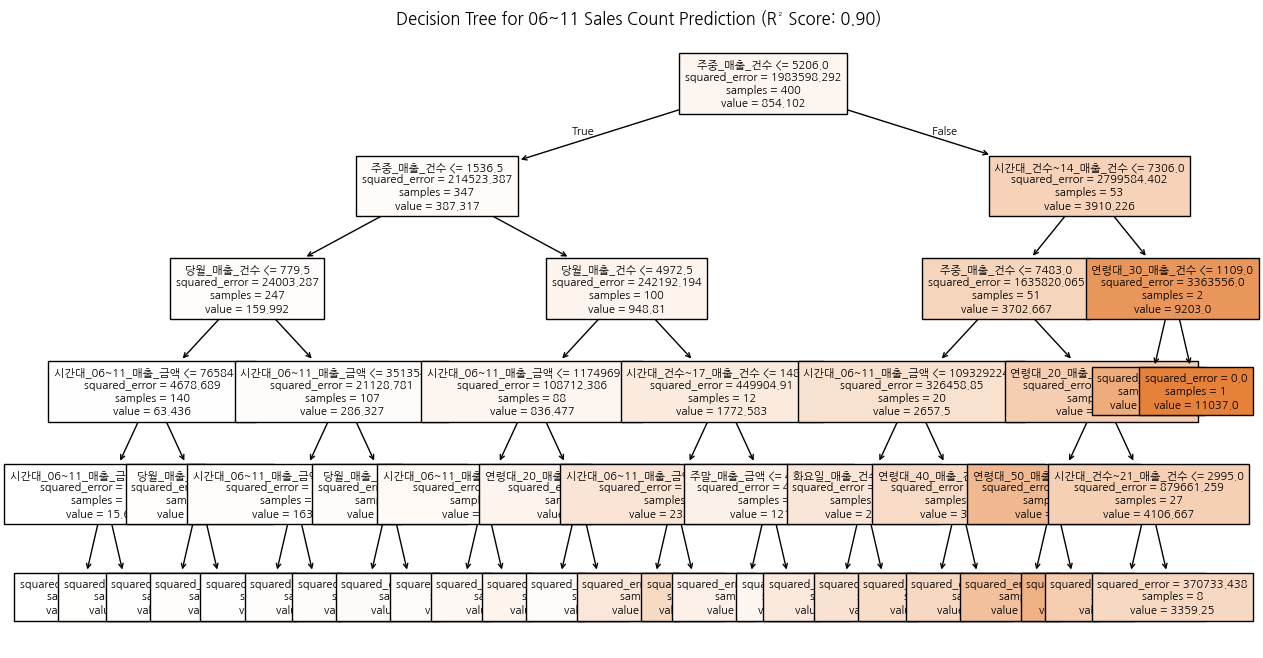

예상 06~11시 매출 건수: 1 건


In [56]:
# 분석에 필요 없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]
df_hardware = df_hardware.drop(columns=drop_columns)

# 결측값 제거
df_hardware = df_hardware.dropna()

# 입력(X)과 타겟(y) 분리
X = df_hardware.drop(columns=["시간대_건수~11_매출_건수"])
y = df_hardware["시간대_건수~11_매출_건수"]

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정트리 모델 학습
dt_model5 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model5.fit(X_train, y_train)

# 모델 예측 및 정확도 평가
y_pred = dt_model5.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 결정 트리 시각화
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model5, feature_names=X.columns, filled=True, ax=ax, fontsize=8)
plt.title(f"Decision Tree for 06~11 Sales Count Prediction (R² Score: {r2:.2f})")
plt.show()

# 예측 함수
def predict_sales_count(data_input):
  input_data = pd.DataFrame([data_input], columns=X.columns)
  prediction = dt_model5.predict(input_data)
  return f"예상 06~11시 매출 건수: {prediction[0]:,.0f} 건"

# 예측 예시
sample_input = X.iloc[0].values # 첫번째 샘플 데이터로 예측
print(predict_sales_count(sample_input))



---

#**랜덤 포레스트 (Random Forest) 개념과 구현**

여러 개의 결정 트리(Decision Tree)를 조합하여 예측 성능을 향상시키는 앙상블 학습(Ensemble Learning) 기법  
단일 결정 트리의 한계를 극복하고 과적합(Overfitting)을 줄이며, 예측 성능을 개선하는 데 효과적

##**1. 랜덤 포레스트 개념**

랜덤 포레스트는 **배깅(Bagging, Bootstrap Aggregating)** 방식을 기반으로 여러 개의 결정 트리를 학습하고,

각 트리의 예측을 **평균(회귀)** 하거나 **투표(분류)** 하여 최종 예측 수행

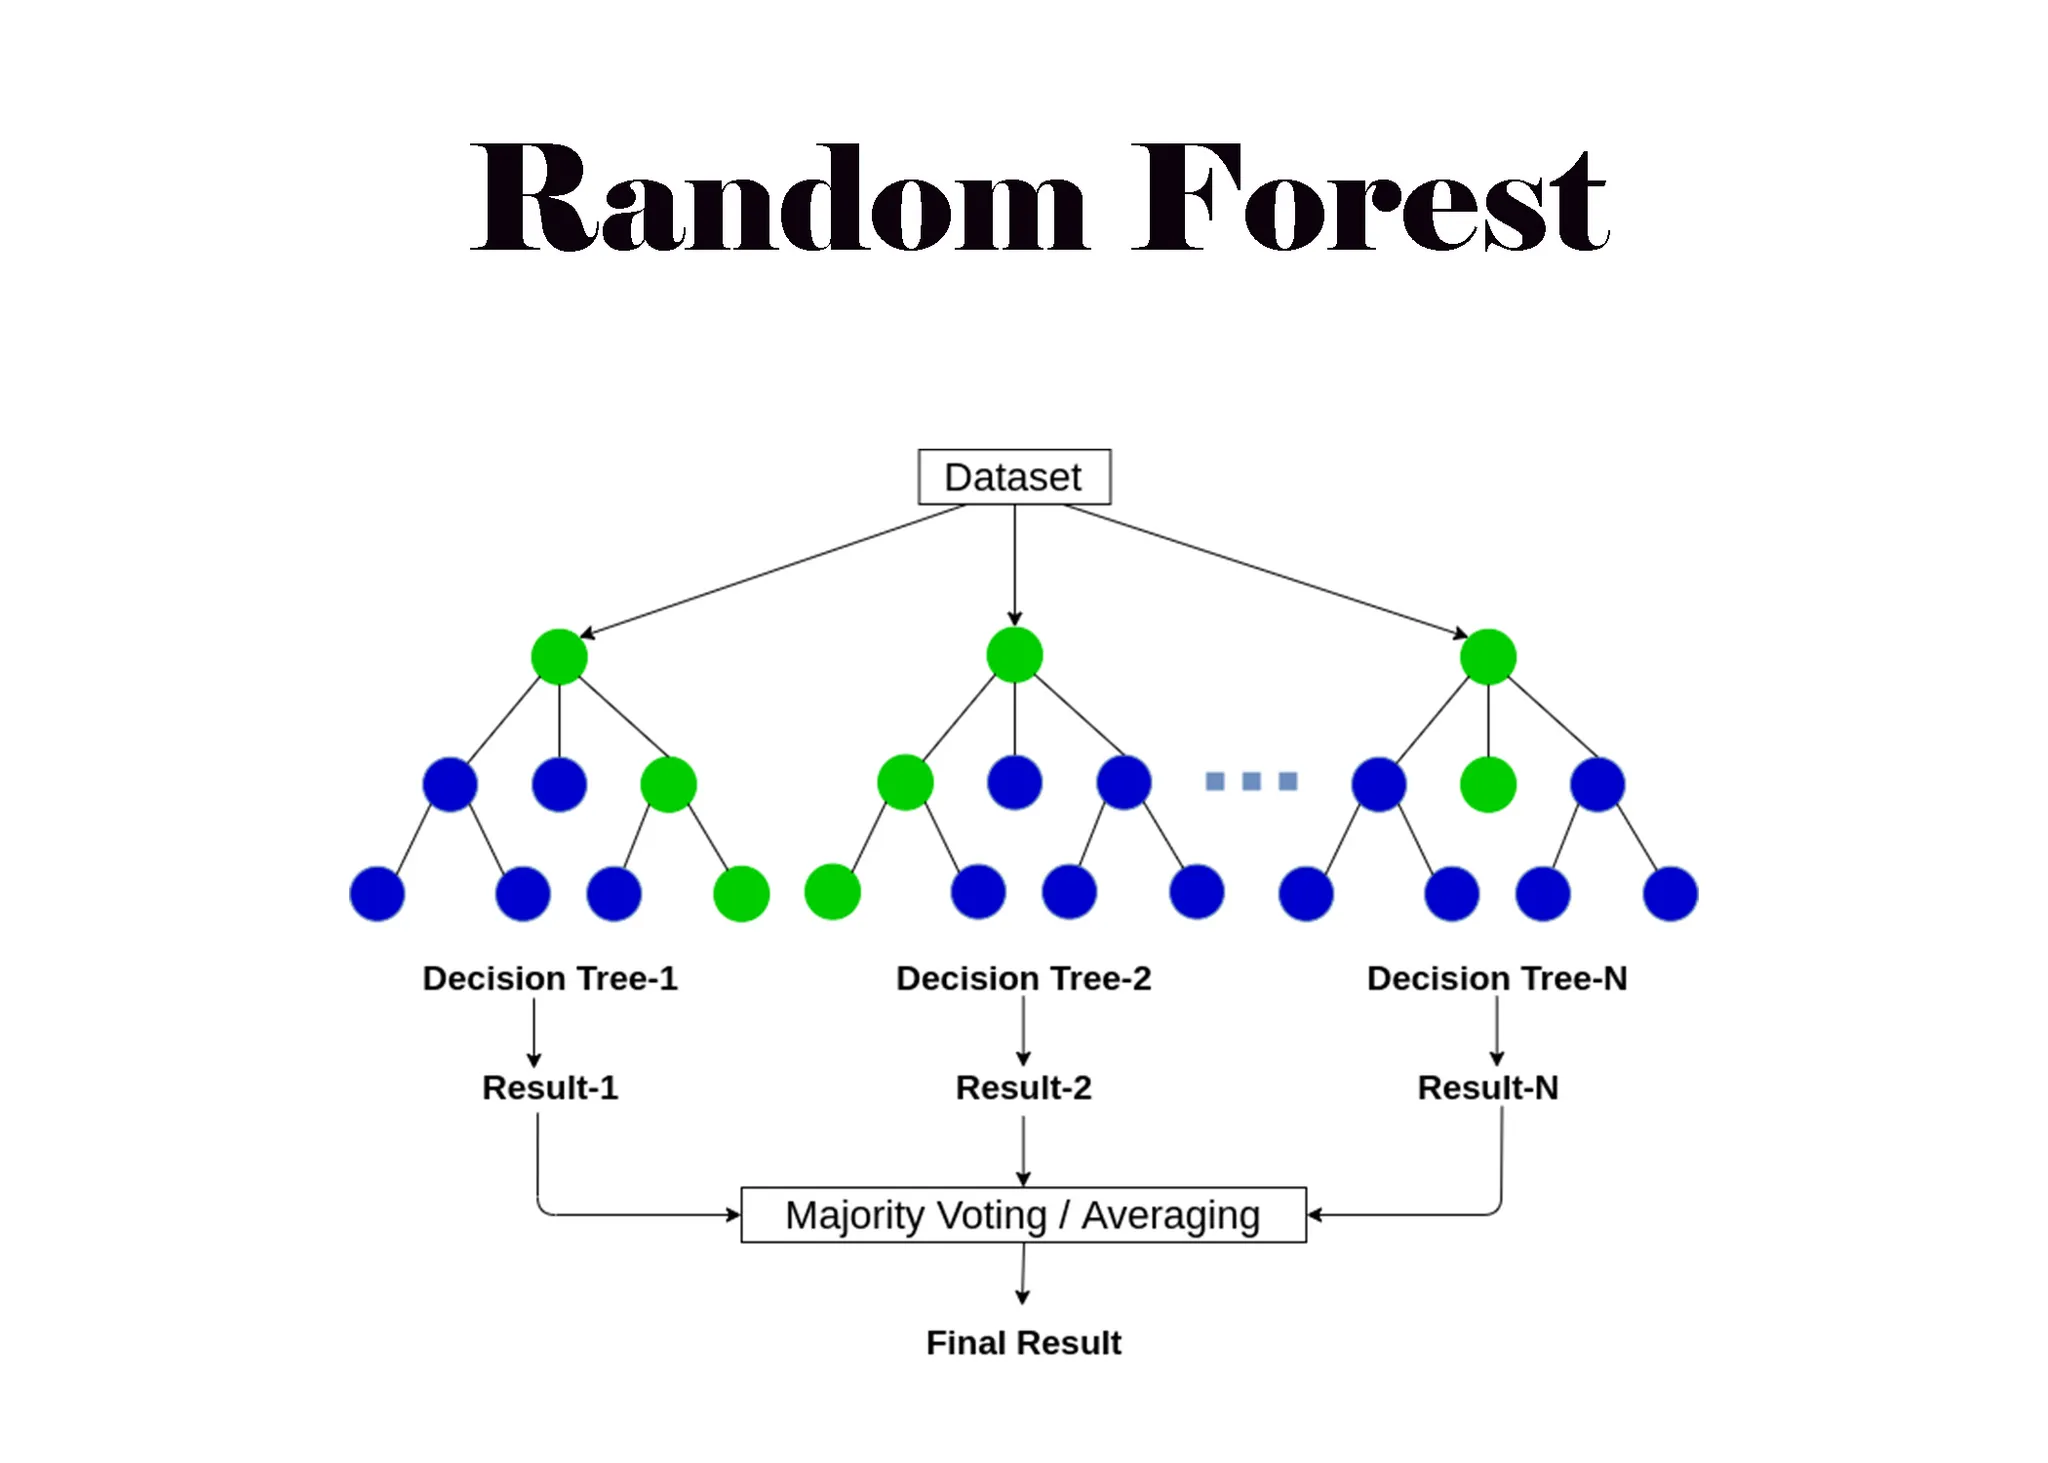

### **랜덤 포레스트의 특징**

1. **여러 개의 결정 트리를 조합하여 예측**
    - 하나의 모델이 아닌 **다수의 결정 트리**를 훈련하여 결과를 조합함
    - 단일 결정 트리보다 **일반화 성능(Generalization)** 이 높아짐
2. **배깅(Bagging) 기법 사용**
    - 데이터 샘플링(부트스트랩 샘플링, Bootstrap Sampling)을 통해 **중복된 데이터를 포함한 여러 개의 훈련 데이터셋**을 생성
    - 각 트리는 **서로 다른 데이터 샘플**을 사용하여 학습됨
3. **랜덤한 특징 선택**
    - 각 트리는 전체 데이터가 아닌 **일부 랜덤한 특징(Feature Subset)** 을 사용하여 분할(Split) 수행
    - 이렇게 하면 **특정 변수에 의존하는 문제를 방지**하고, 모델의 다양성을 증가시킴
4. **결과 결합 방법**
    - **분류(Classification)**: 개별 트리의 예측 중 **가장 많은 표를 받은 클래스(다수결, Majority Voting)** 를 선택
    - **회귀(Regression)**: 개별 트리의 예측값을 **평균** 하여 최종 결과를 생성

## **2. 랜덤 포레스트의 장점과 단점**

### **(1) 장점**

1. **과적합(Overfitting) 방지**
    - 여러 개의 트리를 조합하여 사용하므로 **단일 결정 트리보다 과적합 가능성이 낮음**
2. **높은 예측 성능**
    - 다양한 트리의 결과를 조합하기 때문에 단일 결정 트리보다 **일반화 성능이 뛰어남**
3. **특징 중요도 제공**
    - 랜덤 포레스트는 각 특징(Feature)이 예측에 미치는 영향을 평가할 수 있어 **특징 선택(Feature Selection)에 유용**
4. **다양한 데이터 유형 지원**
    - 숫자형 변수 및 범주형 변수를 모두 처리 가능


### **(2) 단점**

1. **훈련 속도가 느림**
    - 개별 결정 트리 여러 개를 학습해야 하므로 **단일 결정 트리보다 훈련 시간이 오래 걸림**
2. **해석이 어려움**
    - 단일 결정 트리는 해석이 쉽지만, 랜덤 포레스트는 여러 개의 트리를 조합하기 때문에 **직관적으로 이해하기 어려움**
3. **메모리 사용량이 많음**
    - 여러 개의 트리를 저장해야 하므로 **메모리 사용량이 큼**

## **3. 랜덤 포레스트 구현 (그로스 마케팅 예제)**

아래는 랜덤 포레스트를 활용한 **광고 클릭 예측(분류) 및 고객 지출 예측(회귀) 분석** 코드

**광고 클릭 예측**은 **랜덤 포레스트 분류(RandomForestClassifier)** 를 사용하고,

**고객 지출 예측**은 **랜덤 포레스트 회귀(RandomForestRegressor)** 를 사용

[ad_click_prediction.csv](attachment:a568c7ba-d3c8-488b-8ebd-d4416d5c63b5:ad_click_prediction.csv)

### **(1) 광고 클릭 예측 (Random Forest Classification)**

모델 정확도: 0.97
분류 보고서:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.97      1.00      0.98        95

    accuracy                           0.97       100
   macro avg       0.98      0.70      0.78       100
weighted avg       0.97      0.97      0.96       100



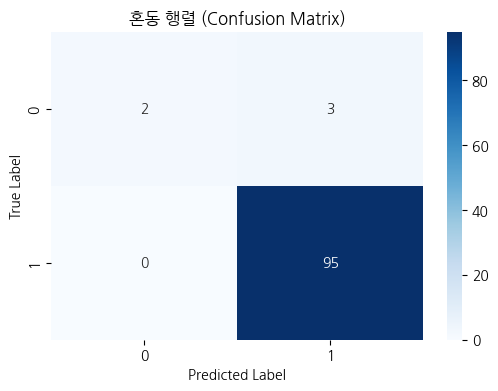

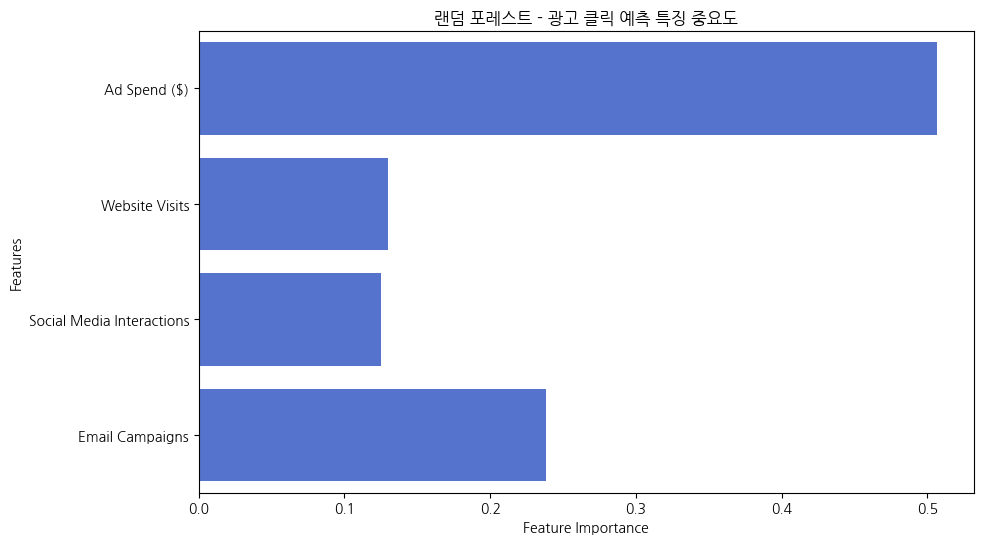

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 데이터 로드
df = pd.read_csv("ad_click_prediction.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Clicked Ad"])
y = df["Clicked Ad"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤 포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf_model.predict(X_test)

print("모델 정확도:", accuracy_score(y_test, y_pred))
print("분류 보고서:\n", classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("혼동 행렬 (Confusion Matrix)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 특징 중요도 시각화
feature_importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_names, color="royalblue")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("랜덤 포레스트 - 광고 클릭 예측 특징 중요도")
plt.show()


[customer_spending_prediction.csv](attachment:a568c7ba-d3c8-488b-8ebd-d4416d5c63b5:customer_spending_prediction.csv)

### **(2) 고객 지출 예측 (Random Forest Regression)**

MSE (Mean Squared Error): 3249.370995415849
R² (결정 계수): 0.8847322748203424


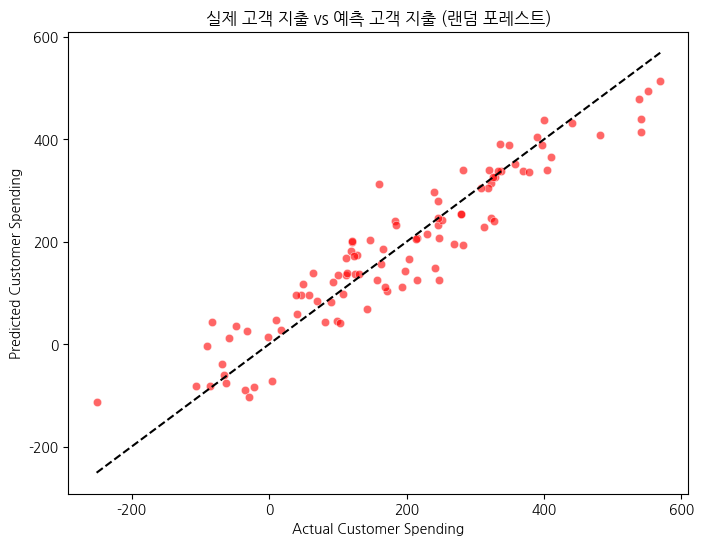

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 로드
df = pd.read_csv("customer_spending_prediction.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Customer Spending ($)"])
y = df["Customer Spending ($)"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤 포레스트 회귀 모델 학습
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_regressor.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf_regressor.predict(X_test)

print("MSE (Mean Squared Error):", mean_squared_error(y_test, y_pred))
print("R² (결정 계수):", r2_score(y_test, y_pred))

# 실제값 vs 예측값 시각화
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="red")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="black")
plt.xlabel("Actual Customer Spending")
plt.ylabel("Predicted Customer Spending")
plt.title("실제 고객 지출 vs 예측 고객 지출 (랜덤 포레스트)")
plt.show()


위 코드를 실행하면 랜덤 포레스트를 활용한 **광고 클릭 예측(분류)** 과 **고객 지출 예측(회귀)** 분석이 가능하다.

1. **광고 클릭 예측 분석**
    - 광고 비용, 웹사이트 방문, SNS 상호작용, 이메일 캠페인 횟수를 고려하여 광고 클릭 가능성을 예측.
    - **혼동 행렬(Confusion Matrix) 및 특징 중요도 그래프**를 통해 중요한 요소 분석 가능.
2. **고객 지출 예측 분석**
    - 고객의 과거 구매 패턴, 멤버십 여부, 마지막 구매 이후 경과일 등을 고려하여 지출 예측.
    - **실제 vs 예측값 그래프**를 통해 예측 성능 평가 가능.

### **(3) 주어진 데이터셋을 이용해 특정 지역의 매출건수예시**

“서울시 상권분석 데이터.csv” 데이터셋을 이용해 “사가정역”에서의 “당월매출건수”를 예측하는 Random forest 회귀 코드 예시 입니다.

Mean Absolute Error (MAE): 1801.12
R² Score: 1.00


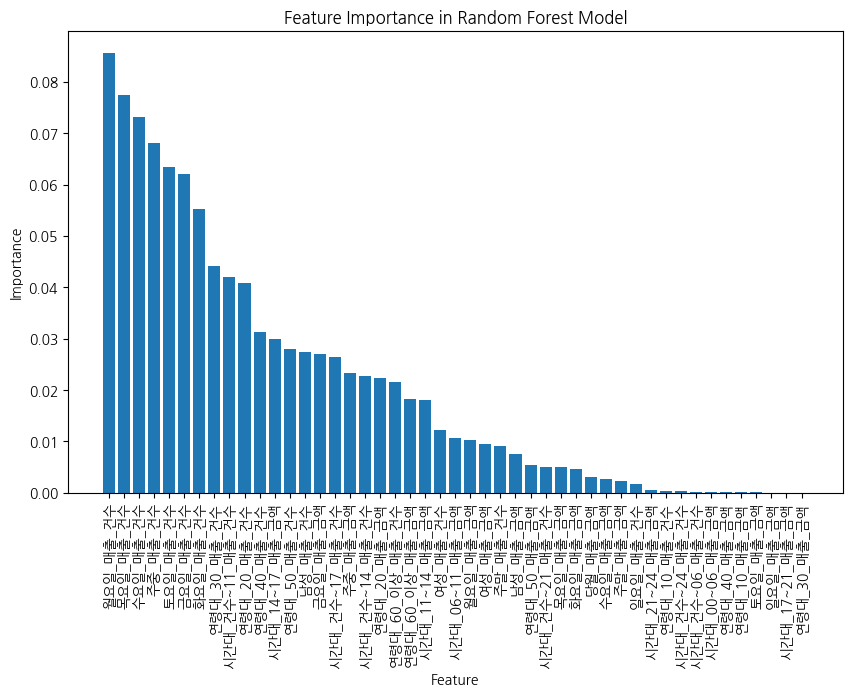

예상 당월 매출 건수: 427 건


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CSV 파일 로드
df = pd.read_csv("서울시상권분석데이터.csv", encoding='utf-8-sig')

# 2. "사가정역" 데이터 필터링
df = df[df["상권_코드_명"] == "사가정역"]

# 3. 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]  # 분석에 불필요한 컬럼 제거
df = df.drop(columns=drop_columns)

# 4. 결측값 제거
df = df.dropna()

# 5. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["당월_매출_건수"])  # 입력 변수
y = df["당월_매출_건수"]  # 타겟 변수 (예측 대상)

# 6. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 랜덤포레스트 회귀 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 8. 모델 예측 및 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. 변수 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 10. 예측 함수
def predict_sales_count(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return f"예상 당월 매출 건수: {prediction[0]:,.0f} 건"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_count(sample_input))


### 숙명적으로 만난 문제

문제 1.  다음의 데이터셋을 이용하여 발달상권의 당월 매출금액을 예측하는 예측모델을 개발하세요

- 랜덤포레스트 알고리즘을 사용해서 예측모델을 만드세요.
- 예측정확도를 90% 이상 충족하고
- 위 예측모델을 만들기 위한 독립변수를 제시하세요.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CSV 파일 로드
df = pd.read_csv("서울시상권분석데이터.csv", encoding='utf-8-sig')
display(df)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20221,D,발달상권,3120068,사가정역,CS200016,당구장,6207432.0,362,3619902.0,...,163,82,347,15,0,42,38,45,150,87
1,20221,A,골목상권,3110316,숭곡초등학교,CS300033,철물점,11755885.0,69,11755885.0,...,0,0,69,0,0,0,0,69,0,0
2,20221,R,전통시장,3130032,인현시장,CS200037,노래방,49610438.0,339,37313834.0,...,255,84,296,0,0,0,169,0,127,0
3,20221,D,발달상권,3120105,상수역(홍대),CS300001,슈퍼마켓,4091445.0,236,2589971.0,...,148,0,0,236,0,148,88,0,0,0
4,20221,A,골목상권,3110431,상계역,CS300001,슈퍼마켓,1828934.0,16,1828934.0,...,6,0,0,16,0,0,0,0,10,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83568,20224,R,전통시장,3130051,동화동 골목형상점가,CS100010,커피-음료,74566607.0,11618,46002960.0,...,811,56,4239,7016,41,1539,2107,2831,2696,2037
83569,20224,A,골목상권,3110121,한양대역 4번,CS100010,커피-음료,496341232.0,74976,343713652.0,...,22056,9747,37372,37498,6632,45799,6409,5767,9168,1094
83570,20224,A,골목상권,3110163,성자초등학교,CS100010,커피-음료,60999234.0,10668,39994099.0,...,2205,349,5054,5440,212,2459,2483,2900,1459,980
83571,20224,A,골목상권,3110110,상왕십리역 6번,CS100010,커피-음료,35826724.0,4681,17309483.0,...,361,0,1811,2870,0,1966,1784,672,155,104


Mean Absolute Error (MAE): 387057364.34
R² Score: 0.99


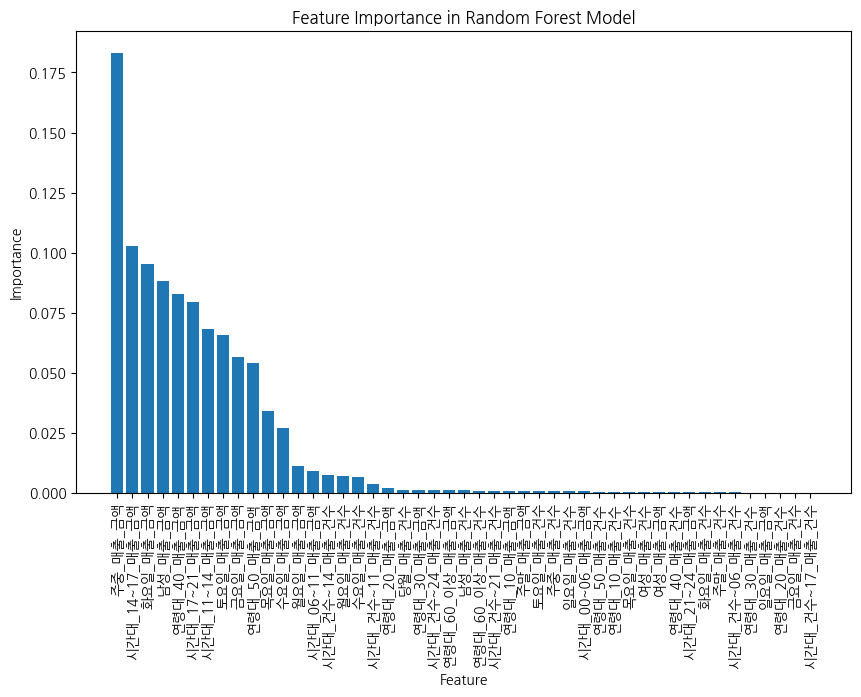

예상 당월 매출 금액: 250,537,662 원


In [67]:
# 2. "발달상권" 데이터 필터링
df_development = df[df["상권_구분_코드_명"] == "발달상권"]

# 3. 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]  # 분석에 불필요한 컬럼 제거
df_development = df_development.drop(columns=drop_columns)

# 4. 결측값 제거
df_development = df_development.dropna()

# 5. 입력(X)과 타겟(y) 분리
X = df_development.drop(columns=["당월_매출_금액"])  # 입력 변수
y = df_development["당월_매출_금액"]  # 타겟 변수 (예측 대상)

# 6. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 랜덤포레스트 회귀 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 8. 모델 예측 및 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. 변수 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 10. 예측 함수
def predict_sales_amount(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return f"예상 당월 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

문제 2. 다음의 내용을 예측하시오.

- 서비스 업종별 당월_매출_금액 예측
- 연령대별 매출 금액 예측
- 시간대별 매출 건수 예측

,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
서비스_업종_코드_명,,,,,,,,,,,,,,,,,,,,,
PC방,3.517172e+08,72080.016055,2.265789e+08,1.251383e+08,4.413774e+07,4.277058e+07,4.414395e+07,4.447865e+07,5.104794e+07,6.523163e+07,...,24037.250000,11154.692661,58228.220183,13843.330275,8867.094037,38669.153670,14922.222477,4275.277523,4475.472477,862.332569
가구,1.315598e+09,3497.585714,9.151505e+08,4.004476e+08,1.748145e+08,2.050113e+08,1.618736e+08,1.973114e+08,1.761397e+08,2.309723e+08,...,527.020408,1.865306,1670.693878,1494.195918,6.016327,375.153061,765.440816,695.459184,745.326531,577.618367
가방,6.737526e+08,17009.363636,4.364039e+08,2.373487e+08,8.208242e+07,8.110596e+07,1.002215e+08,7.904411e+07,9.394988e+07,1.292736e+08,...,6470.695652,648.624506,5516.517787,11302.952569,263.169960,4248.715415,4494.581028,3126.517787,2630.142292,2056.422925
가전제품,3.109442e+09,8742.084548,1.964746e+09,1.144701e+09,5.029969e+08,3.661518e+08,3.493411e+08,3.488981e+08,3.973564e+08,5.822088e+08,...,2567.029155,38.848397,4943.679300,3367.591837,18.591837,625.755102,1626.489796,1808.306122,1971.562682,2260.527697
가전제품수리,1.698307e+08,2036.818182,1.522154e+08,1.761524e+07,3.187809e+07,2.915320e+07,3.000081e+07,3.230989e+07,2.887345e+07,1.643295e+07,...,275.021390,3.502674,1041.898396,824.443850,2.245989,111.577540,322.224599,412.550802,458.860963,558.893048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
한의원,5.191844e+08,12377.995157,4.174001e+08,1.017843e+08,9.196671e+07,8.703115e+07,7.383419e+07,7.227126e+07,9.229679e+07,9.358466e+07,...,2634.413236,12.318805,5331.134786,7016.613398,22.123487,791.962873,1771.966102,2285.520581,2771.034705,4705.107345
핸드폰,2.757362e+08,6293.442647,2.148400e+08,6.089617e+07,4.556169e+07,4.168784e+07,3.877800e+07,4.334776e+07,4.546473e+07,4.134760e+07,...,2097.707353,92.173529,3063.664706,2948.492647,87.330882,1287.150000,1206.601471,1190.333824,1310.991176,929.697059
호프-간이주점,6.507164e+08,12352.650800,4.322287e+08,2.184877e+08,6.983126e+07,7.933294e+07,8.465124e+07,8.861088e+07,1.098024e+08,1.318494e+08,...,3159.172887,5388.498096,7305.667174,4432.456588,193.577685,4448.684311,3310.178979,1653.994669,1428.299695,703.477532


Mean Absolute Error (MAE): 307386666.49
R² Score: -0.61


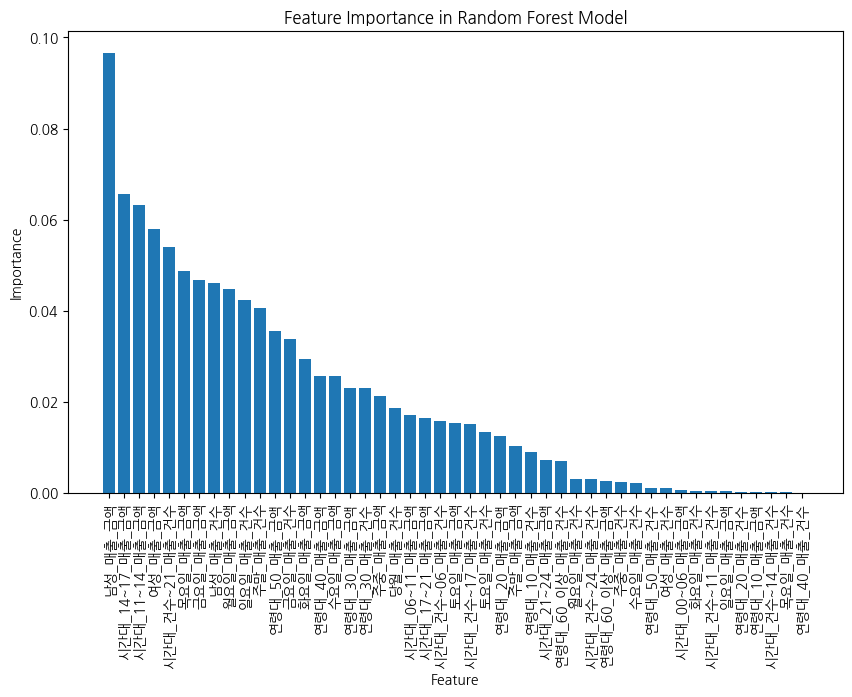

예상 당월 매출 금액: 1,103,813,340 원


In [85]:
# [서비스 업종별 당월_매출_금액 예측]

# 2. 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드"]  # 분석에 불필요한 컬럼 제거

# 3. "서비스 업종별" 데이터 그룹화
df_service = df.drop(columns=drop_columns).groupby("서비스_업종_코드_명").mean()
display(df_service)

# 4. 결측값 제거
#df_service = df_service.dropna()

# 5. 입력(X)과 타겟(y) 분리
X = df_service.drop(columns=["당월_매출_금액"])  # 입력 변수
y = df_service["당월_매출_금액"]  # 타겟 변수 (예측 대상)

# 6. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 랜덤포레스트 회귀 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 8. 모델 예측 및 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. 변수 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 10. 예측 함수
def predict_sales_amount(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return f"예상 당월 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,6207432.0,362,3619902.0,2587530.0,879610.0,1366939.0,424717.0,367007.0,581629.0,1382783.0,...,163,82,347,15,0,42,38,45,150,87
1,11755885.0,69,11755885.0,0.0,0.0,0.0,0.0,0.0,11755885.0,0.0,...,0,0,69,0,0,0,0,69,0,0
2,49610438.0,339,37313834.0,12296604.0,0.0,8480417.0,0.0,28833417.0,0.0,12296604.0,...,255,84,296,0,0,0,169,0,127,0
3,4091445.0,236,2589971.0,1501474.0,0.0,755163.0,353982.0,1244838.0,235988.0,1501474.0,...,148,0,0,236,0,148,88,0,0,0
4,1828934.0,16,1828934.0,0.0,272975.0,1555959.0,0.0,0.0,0.0,0.0,...,6,0,0,16,0,0,0,0,10,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83568,74566607.0,11618,46002960.0,28563647.0,6888550.0,8896483.0,9061363.0,8667861.0,12488703.0,9673626.0,...,811,56,4239,7016,41,1539,2107,2831,2696,2037
83569,496341232.0,74976,343713652.0,152627580.0,69315709.0,73849753.0,72567043.0,58950905.0,69030242.0,77055692.0,...,22056,9747,37372,37498,6632,45799,6409,5767,9168,1094
83570,60999234.0,10668,39994099.0,21005135.0,6442356.0,7478408.0,6236560.0,9338456.0,10498319.0,11736075.0,...,2205,349,5054,5440,212,2459,2483,2900,1459,980
83571,35826724.0,4681,17309483.0,18517241.0,5314656.0,3331034.0,3698276.0,0.0,4965517.0,9129309.0,...,361,0,1811,2870,0,1966,1784,672,155,104


Mean Absolute Error (MAE): 52015850.58
R² Score: 0.93


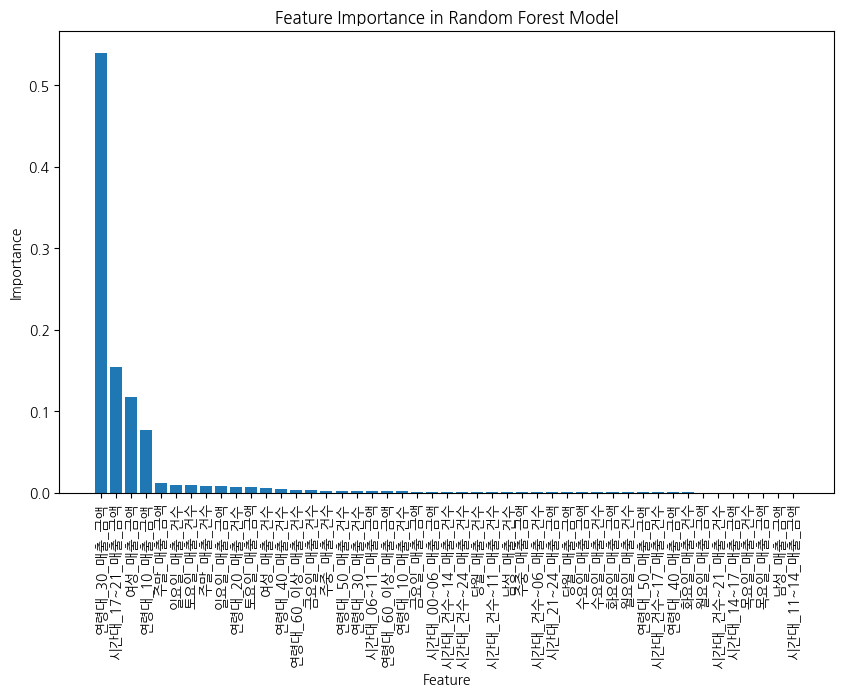

예상 20대 매출 금액: 13,055,467 원


In [86]:
# [연령대별(20대) 매출 금액 예측]

# 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]  # 분석에 불필요한 컬럼 제거

df_age = df.drop(columns=drop_columns)
display(df_age)

# 결측값 제거
df_age = df_age.dropna()

# 입력(X)과 타겟(y) 분리
X = df_age.drop(columns=["연령대_20_매출_금액"])  # 입력 변수
y = df_age["연령대_20_매출_금액"]  # 타겟 변수 (예측 대상)

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤포레스트 회귀 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 모델 예측 및 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 변수 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 예측 함수
def predict_sales_amount(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return f"예상 20대 매출 금액: {prediction[0]:,.0f} 원"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_amount(sample_input))

,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,6207432.0,362,3619902.0,2587530.0,879610.0,1366939.0,424717.0,367007.0,581629.0,1382783.0,...,163,82,347,15,0,42,38,45,150,87
1,11755885.0,69,11755885.0,0.0,0.0,0.0,0.0,0.0,11755885.0,0.0,...,0,0,69,0,0,0,0,69,0,0
2,49610438.0,339,37313834.0,12296604.0,0.0,8480417.0,0.0,28833417.0,0.0,12296604.0,...,255,84,296,0,0,0,169,0,127,0
3,4091445.0,236,2589971.0,1501474.0,0.0,755163.0,353982.0,1244838.0,235988.0,1501474.0,...,148,0,0,236,0,148,88,0,0,0
4,1828934.0,16,1828934.0,0.0,272975.0,1555959.0,0.0,0.0,0.0,0.0,...,6,0,0,16,0,0,0,0,10,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83568,74566607.0,11618,46002960.0,28563647.0,6888550.0,8896483.0,9061363.0,8667861.0,12488703.0,9673626.0,...,811,56,4239,7016,41,1539,2107,2831,2696,2037
83569,496341232.0,74976,343713652.0,152627580.0,69315709.0,73849753.0,72567043.0,58950905.0,69030242.0,77055692.0,...,22056,9747,37372,37498,6632,45799,6409,5767,9168,1094
83570,60999234.0,10668,39994099.0,21005135.0,6442356.0,7478408.0,6236560.0,9338456.0,10498319.0,11736075.0,...,2205,349,5054,5440,212,2459,2483,2900,1459,980
83571,35826724.0,4681,17309483.0,18517241.0,5314656.0,3331034.0,3698276.0,0.0,4965517.0,9129309.0,...,361,0,1811,2870,0,1966,1784,672,155,104


Mean Absolute Error (MAE): 2095.65
R² Score: 0.96


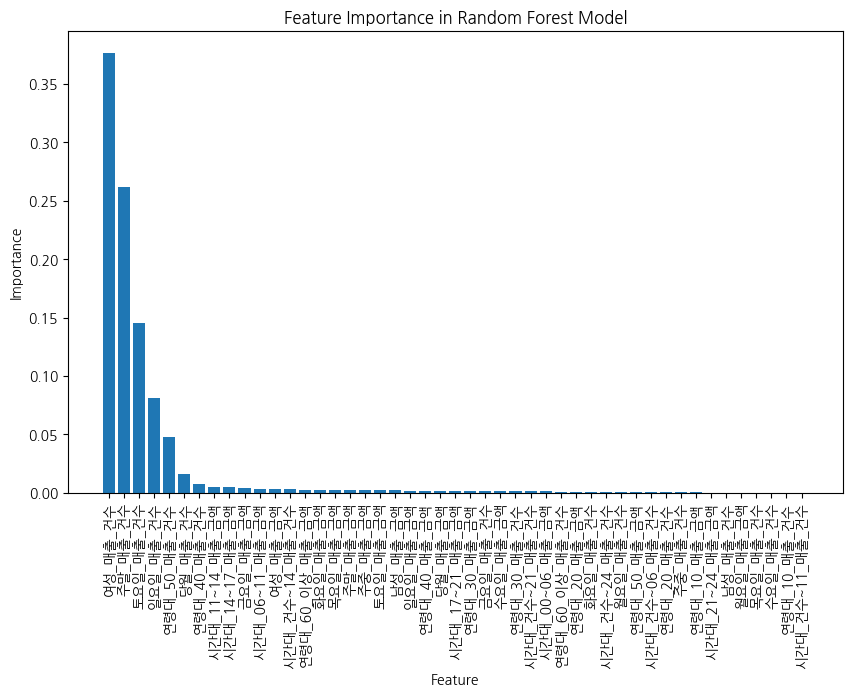

예상 14~17시 매출 건수: 561 건


In [87]:
# [시간대별(14~17시) 매출 건수 예측]

# 필요없는 컬럼 제거
drop_columns = ["기준_년분기_코드", "상권_구분_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
                "서비스_업종_코드", "서비스_업종_코드_명"]  # 분석에 불필요한 컬럼 제거

df_time = df.drop(columns=drop_columns)

# 결측값 제거
df_time = df_time.dropna()
display(df_time)

# 입력(X)과 타겟(y) 분리
X = df_time.drop(columns=["시간대_건수~17_매출_건수"])  # 입력 변수
y = df_time["시간대_건수~17_매출_건수"]  # 타겟 변수 (예측 대상)

# 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤포레스트 회귀 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 모델 예측 및 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 변수 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 예측 함수
def predict_sales_count(data_input):
    input_data = pd.DataFrame([data_input], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return f"예상 14~17시 매출 건수: {prediction[0]:,.0f} 건"

# 예측 예시
sample_input = X.iloc[0].values  # 첫 번째 샘플 데이터로 예측
print(predict_sales_count(sample_input))



---

## **예제 1: 온라인 쇼핑몰에서 고객 반품 예측**



### **1. 데이터 시나리오**

한 온라인 쇼핑몰이 고객의 반품(Return) 여부를 예측하고자 한다.

특정 고객이 주문한 상품을 반품할 가능성이 있는지를 분석하여 **반품률을 줄이고 고객 만족도를 높이려는 전략**을 세운다.

### **데이터 변수**

- **구매 금액(Total_Spend)**: 고객이 해당 주문에서 지출한 총 금액
- **구매 제품 수(Items_Purchased)**: 한 번의 주문에서 구매한 제품 수
- **배송 기간(Delivery_Days)**: 고객이 제품을 배송받는 데 걸린 시간 (일 단위)
- **할인 사용 여부(Used_Coupon)**: 할인 쿠폰을 사용했는지 여부 (1: 예, 0: 아니오)
- **반품 여부(Returned_Item)**: 고객이 반품했는지 여부 (목표 변수, 1: 반품, 0: 반품 안 함)



### **2. 모델의 목적**

1. **반품 가능성이 높은 주문을 예측하여 맞춤형 고객 서비스 제공**
2. **반품 원인 분석(예: 긴 배송 기간, 낮은 구매 금액 등) 및 개선 전략 수립**
3. **반품을 줄여 기업의 물류 비용 절감 및 고객 만족도 증가**



### **3. 파이썬 코드 (랜덤포레스트 모델 구축 및 예측)**

모델 정확도(Accuracy): 0.50


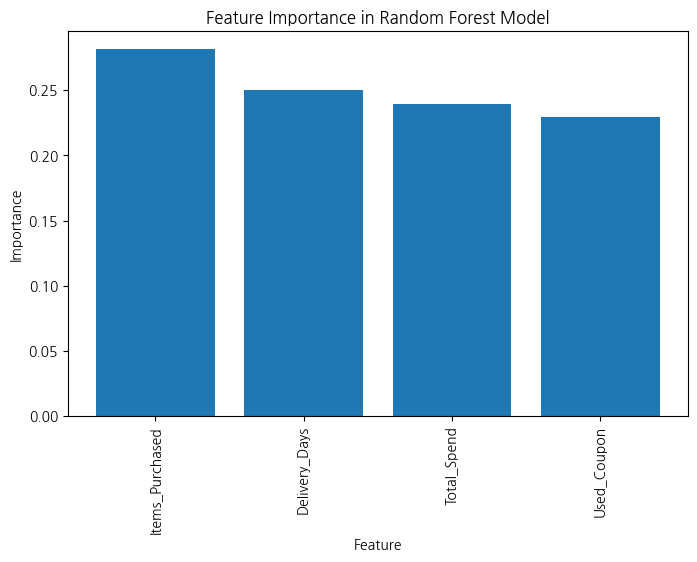

예측 결과: 반품하지 않을 가능성이 높음


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 가상의 반품 데이터 생성
data = {
    "Total_Spend": [30, 200, 80, 150, 10, 250, 50, 180, 90, 40],
    "Items_Purchased": [1, 5, 3, 4, 1, 6, 2, 4, 3, 2],
    "Delivery_Days": [2, 5, 3, 7, 1, 10, 2, 6, 5, 2],
    "Used_Coupon": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Returned_Item": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 반품, 0: 반품 안 함
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Returned_Item"])  # 독립 변수
y = df["Returned_Item"]  # 종속 변수 (반품 여부 예측)

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy:.2f}")

# 7. 특징 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 8. 반품 예측 함수
def predict_return(Total_Spend, Items_Purchased, Delivery_Days, Used_Coupon):
    input_data = pd.DataFrame([[Total_Spend, Items_Purchased, Delivery_Days, Used_Coupon]],
                              columns=X.columns)
    prediction = rf_model.predict(input_data)
    return "반품 가능성이 높음" if prediction[0] == 1 else "반품하지 않을 가능성이 높음"

# 9. 예측 함수 실행 예시
sample_prediction = predict_return(100, 3, 4, 1)
print(f"예측 결과: {sample_prediction}")


- **모델 정확도 향상 필요**

모델 정확도(Accuracy): 1.00


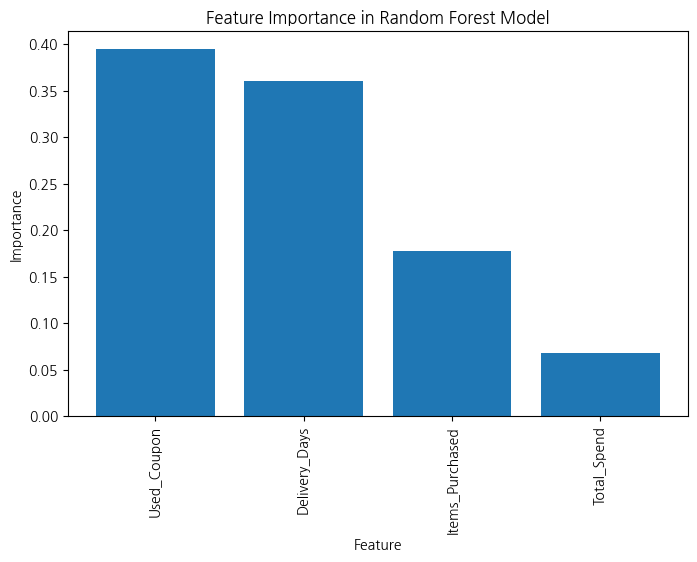

예측 결과: 반품하지 않을 가능성이 높음


In [72]:
# 데이터 재생성 (성능 개선 목적)
data = {
    "Total_Spend": [130, 200, 180, 150, 110, 250, 150, 180, 190, 220],
    "Items_Purchased": [1, 5, 3, 4, 1, 6, 3, 4, 3, 7],
    "Delivery_Days": [2, 5, 3, 7, 1, 10, 2, 6, 5, 2],
    "Used_Coupon": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Returned_Item": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 반품, 0: 반품 안 함
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Returned_Item"])  # 독립 변수
y = df["Returned_Item"]  # 종속 변수 (반품 여부 예측)

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy:.2f}")

# 7. 특징 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 8. 반품 예측 함수
def predict_return(Total_Spend, Items_Purchased, Delivery_Days, Used_Coupon):
    input_data = pd.DataFrame([[Total_Spend, Items_Purchased, Delivery_Days, Used_Coupon]],
                              columns=X.columns)
    prediction = rf_model.predict(input_data)
    return "반품 가능성이 높음" if prediction[0] == 1 else "반품하지 않을 가능성이 높음"

# 9. 예측 함수 실행 예시
sample_prediction = predict_return(100, 3, 4, 1)
print(f"예측 결과: {sample_prediction}")

## **예제 2: 신용카드 사기 탐지**


### **1. 데이터 시나리오**

한 금융기관이 **신용카드 사기(Fraud) 여부를 예측**하고자 한다.

거래 데이터를 분석하여 **정상 거래와 사기 거래를 구분**하고 금융 보안을 강화한다.

### **데이터 변수**

- **거래 금액(Transaction_Amount)**: 거래에서 사용된 금액
- **거래 횟수(Daily_Transactions)**: 하루 동안 발생한 거래 횟수
- **해외 거래 여부(International_Transaction)**: 해외 거래인지 여부 (1: 예, 0: 아니오)
- **고위험 국가 거래 여부(High_Risk_Country)**: 고위험 국가에서 발생한 거래인지 여부 (1: 예, 0: 아니오)
- **사기 여부(Fraudulent)**: 거래가 사기인지 여부 (목표 변수, 1: 사기, 0: 정상)


### **2. 모델의 목적**

1. **실시간 신용카드 거래에서 사기 가능성이 높은 거래 감지**
2. **정상 거래와 사기 거래 패턴 분석을 통한 금융 보안 강화**
3. **고객 피해 예방 및 신용카드 사용의 신뢰도 향상**


### **3. 파이썬 코드 (랜덤포레스트 모델 구축 및 예측)**

모델 정확도(Accuracy): 0.50


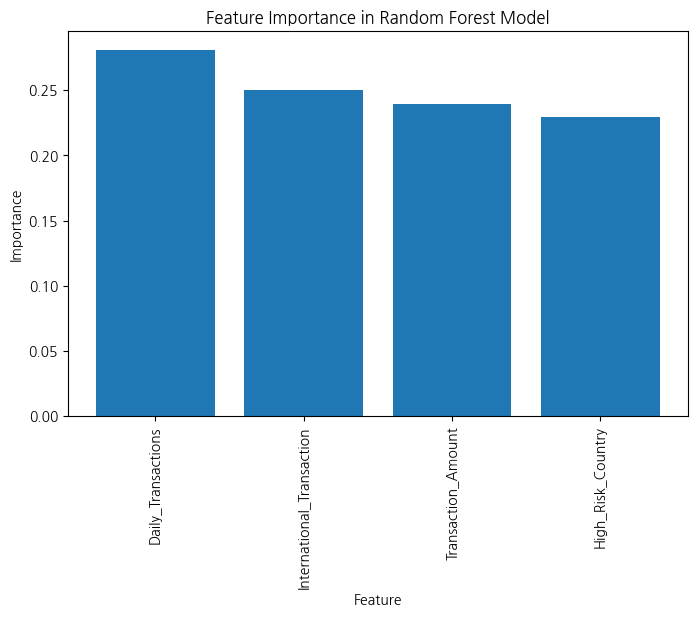

예측 결과: 사기 거래 가능성이 높음


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 가상의 신용카드 사기 데이터 생성
data = {
    "Transaction_Amount": [100, 5000, 200, 7000, 50, 8000, 150, 6000, 250, 90],
    "Daily_Transactions": [5, 50, 10, 70, 3, 80, 7, 60, 12, 6],
    "International_Transaction": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "High_Risk_Country": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Fraudulent": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 사기, 0: 정상
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Fraudulent"])  # 입력 변수
y = df["Fraudulent"]  # 타겟 변수 (사기 거래 여부)

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy:.2f}")

# 7. 특징 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 8. 사기 거래 예측 함수
def predict_fraud(Transaction_Amount, Daily_Transactions, International_Transaction, High_Risk_Country):
    input_data = pd.DataFrame([[Transaction_Amount, Daily_Transactions, International_Transaction, High_Risk_Country]],
                              columns=X.columns)
    prediction = rf_model.predict(input_data)
    return "사기 거래 가능성이 높음" if prediction[0] == 1 else "정상 거래 가능성이 높음"

# 9. 예측 함수 실행 예시
sample_prediction = predict_fraud(6000, 55, 1, 1)
print(f"예측 결과: {sample_prediction}")


- **모델 정확도 향상 필요**

모델 정확도(Accuracy): 1.00


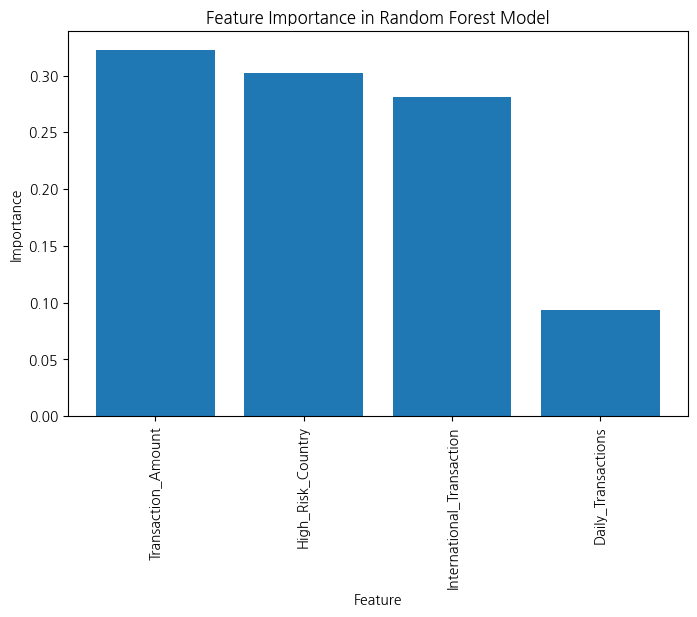

예측 결과: 사기 거래 가능성이 높음


In [77]:
data = {
    "Transaction_Amount": [3100, 5000, 2000, 7000, 1500, 8000, 1100, 6000, 2500, 900],
    "Daily_Transactions": [35, 38, 15, 40, 10, 50, 55, 45, 12, 6],
    "International_Transaction": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "High_Risk_Country": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    "Fraudulent": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 1: 사기, 0: 정상
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Fraudulent"])  # 입력 변수
y = df["Fraudulent"]  # 타겟 변수 (사기 거래 여부)

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy:.2f}")

# 7. 특징 중요도 시각화
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align="center")
plt.xticks(range(X.shape[1]), X.columns[sorted_idx], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

# 8. 사기 거래 예측 함수
def predict_fraud(Transaction_Amount, Daily_Transactions, International_Transaction, High_Risk_Country):
    input_data = pd.DataFrame([[Transaction_Amount, Daily_Transactions, International_Transaction, High_Risk_Country]],
                              columns=X.columns)
    prediction = rf_model.predict(input_data)
    return "사기 거래 가능성이 높음" if prediction[0] == 1 else "정상 거래 가능성이 높음"

# 9. 예측 함수 실행 예시
sample_prediction = predict_fraud(6000, 55, 1, 1)
print(f"예측 결과: {sample_prediction}")


## **예제 3: 음식 배달 서비스에서 고객 이탈 예측**


### **1. 데이터 시나리오**

한 음식 배달 플랫폼이 **고객 이탈(Churn) 가능성을 예측**하고자 한다.

사용자의 주문 패턴을 분석하여 **이탈 가능성이 높은 고객에게 맞춤형 할인 제공**.

### **데이터 변수**

- **월 주문 횟수(Monthly_Orders)**: 고객이 한 달 동안 주문한 횟수
- **평균 주문 금액(Avg_Order_Value)**: 고객의 평균 주문 금액
- **리뷰 점수(Review_Score)**: 고객이 남긴 평균 리뷰 점수 (1~5)
- **이탈 여부(Churned)**: 고객이 이탈했는지 여부 (목표 변수, 1: 이탈, 0: 유지)



### **2. 모델의 목적**

1. **이탈 가능성이 높은 고객을 식별하여 고객 유지 전략 적용**
2. **할인 쿠폰 제공, 추천 시스템 개선을 통한 이탈률 감소**
3. **고객 만족도를 분석하여 서비스 품질 개선**



### **3. 파이썬 코드 (랜덤포레스트 모델 구축 및 예측)**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 가상의 고객 이탈 데이터 생성
data = {
    "Monthly_Orders": [5, 12, 3, 15, 2, 20, 4, 18, 7, 6],
    "Avg_Order_Value": [15, 35, 10, 50, 8, 55, 12, 40, 20, 14],
    "Review_Score": [4.2, 4.8, 3.5, 4.9, 2.9, 5.0, 3.0, 4.6, 4.0, 3.8],
    "Churned": [1, 0, 1, 0, 1, 0, 1, 0, 0, 1]  # 1: 이탈, 0: 유지
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)

# 3. 입력(X)과 타겟(y) 분리
X = df.drop(columns=["Churned"])
y = df["Churned"]

# 4. 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 모델 예측 및 정확도 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 7. 랜덤포레스트 모델 평가
print(f"모델 정확도: {accuracy:.2f}")

# 8. 고객 이탈 예측 함수
def predict_churn(Monthly_Orders, Avg_Order_Value, Review_Score):
    """
    입력한 고객 데이터를 기반으로 이탈 여부를 예측하는 함수
    """
    input_data = pd.DataFrame([[Monthly_Orders, Avg_Order_Value, Review_Score]], columns=X.columns)
    prediction = rf_model.predict(input_data)
    return "고객이 이탈할 가능성이 높음" if prediction[0] == 1 else "고객이 계속 유지될 가능성이 높음"

# 9. 예제 입력 데이터 및 예측 실행
example_input = {"Monthly_Orders": 5, "Avg_Order_Value": 15, "Review_Score": 4.2}
prediction_result = predict_churn(**example_input)
print(f"예측 결과: {prediction_result}")


모델 정확도: 0.50
예측 결과: 고객이 이탈할 가능성이 높음
